# Week 2 Milestone Submission
## IDX Next-Day Price Direction Prediction

This compiled notebook merges the full project workflow into one submission artifact:

1. Business understanding, EDA, and cleaning
2. Feature engineering and processed dataset construction
3. Topic C-compliant modeling universe reduction, 40-feature capping, classifier training, and evaluation

Final modeling configuration:

- Sectors: Energy and Technology
- Modeling universe: 56 Energy + 44 Technology = 100 tickers
- Candidate engineered features: 77
- Final selected features: top 40, selected using training data only
- Baseline: Logistic Regression
- Final selected model: Random Forest
- Temporal evaluation: train through 2022, validation in 2023, test in 2024

The source notebook outputs are preserved below so the submission remains auditable.

---
# Part 1: Business Understanding, Data Understanding, EDA, and Cleaning

Source notebook: `01_EDA_cleaning.ipynb`. Covers Kaggle data loading, 2020-2024 filtering, EDA, IDX-IC sector mapping, suspended-ticker handling, cleaning, and cleaned OHLCV export.

# IDX Next-Day Price Direction Prediction

## Phase 1: Setup & Data Acquisition

**Goal**: Predict whether a stock's closing price on day `t+1` will be higher or lower than on day `t` using only historical OHLCV data up to day `t`.

**Dataset**: `eren2222/complete-indonesia-stock-exchange-idx-2000-2024` from Kaggle

**Target**: Binary classification
- `1` = Close(t+1) > Close(t) — Price goes **Up**
- `0` = Close(t+1) <= Close(t) — Price goes **Down or Flat**

Constraints: Prevent data leakage!! features derived exclusively from data prior to day `t`.

In [1]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# =============================================================================
# imports and config
# =============================================================================
import os
import sys
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Suppress warnings for cleaner output during exploration
warnings.filterwarnings('ignore')

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Prefer the complete Kaggle dataset. The bundled project CSV is a local
# fallback for offline reruns or environments with a broken Kaggle client.
LOCAL_DATA_PATH = os.path.join('Dataset', 'cleaned_data.csv')
try:
    import kagglehub

    DATA_DIR = kagglehub.dataset_download(
        "eren2222/complete-indonesia-stock-exchange-idx-2000-2024"
    )
    DATA_PATH = os.path.join(DATA_DIR, "IDX 2000-2024.csv")
    print(f"Using Kaggle dataset CSV: {DATA_PATH}")
except Exception as exc:
    if not os.path.exists(LOCAL_DATA_PATH):
        raise
    DATA_PATH = LOCAL_DATA_PATH
    print(f"Kaggle dataset unavailable ({type(exc).__name__}); "
          f"using bundled project CSV: {DATA_PATH}")

# Project scope: only 2020-2024 per GOAL.md
START_DATE = "2020-01-01"
END_DATE   = "2024-12-31"

print("=" * 70)
print("IDX NEXT-DAY PRICE DIRECTION PREDICTION")
print("=" * 70)
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Python: {sys.version.split()[0]}")
print(f"Pandas: {pd.__version__}, NumPy: {np.__version__}")
print(f"Date range: {START_DATE} to {END_DATE}")
print("=" * 70)


Kaggle dataset unavailable (ImportError); using bundled project CSV: Dataset\cleaned_data.csv
IDX NEXT-DAY PRICE DIRECTION PREDICTION
Timestamp: 2026-05-30 20:12:57
Python: 3.12.5
Pandas: 3.0.1, NumPy: 2.4.3
Date range: 2020-01-01 to 2024-12-31


In [3]:
# The dataset has been pre-downloaded via kagglehub.
# If you need to re-download, uncomment the code below:

# import kagglehub
# download_path = kagglehub.dataset_download("eren2222/complete-indonesia-stock-exchange-idx-2000-2024")
# print("Downloaded to:", download_path)

# Verify the data file exists
if os.path.exists(DATA_PATH):
    file_size_gb = os.path.getsize(DATA_PATH) / (1024 ** 3)
    print(f"✓ Data file found: {DATA_PATH}")
    print(f"  File size: {file_size_gb:.2f} GB")
else:
    print(f"✗ Data file NOT found at: {DATA_PATH}")
    print("Please download the dataset first using kagglehub.")

✓ Data file found: Dataset\cleaned_data.csv
  File size: 0.01 GB


In [4]:
# inspect column names and data types
df_preview = pd.read_csv(DATA_PATH, nrows=10)

print("Column Names:")
print(df_preview.columns.tolist())
print("\nData Types:")
print(df_preview.dtypes)
print("\nFirst 5 rows:")
print(df_preview.head())

Column Names:
['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'sector']

Data Types:
Date             str
Ticker           str
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume       float64
sector           str
dtype: object

First 5 rows:
         Date Ticker    Open    High     Low   Close    Adj Close  Volume  \
0  2020-01-13   ABMM  1300.0  1515.0  1300.0  1515.0  1214.466431   500.0   
1  2020-01-16   ABMM  1495.0  1495.0  1490.0  1490.0  1194.425781  1500.0   
2  2020-01-20   ABMM  1490.0  1490.0  1490.0  1490.0  1194.425781  6000.0   
3  2020-01-23   ABMM  1475.0  1480.0  1470.0  1480.0  1186.409424   800.0   
4  2020-01-28   ABMM  1450.0  1450.0  1450.0  1450.0  1162.360596   100.0   

   sector  
0  Energy  
1  Energy  
2  Energy  
3  Energy  
4  Energy  


In [5]:
# ds scaling; high level stats (2020–2024)
# to handle large files, read in chunks for aggregation

CHUNK_SIZE = 500_000  # rows per chunk

total_rows = 0
unique_tickers = set()
all_dates = []
chunk_count = 0

print("Reading dataset in chunks for 2020–2024...")
for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE, usecols=['Date', 'Ticker']):
    chunk['Date'] = pd.to_datetime(chunk['Date'])
    mask = (chunk['Date'] >= START_DATE) & (chunk['Date'] <= END_DATE)
    chunk = chunk[mask]
    if len(chunk) == 0:
        continue
    total_rows += len(chunk)
    unique_tickers.update(chunk['Ticker'].unique())
    all_dates.extend([chunk['Date'].iloc[0], chunk['Date'].iloc[-1]])
    chunk_count += 1
    if chunk_count % 5 == 0:
        print(f"  Processed {chunk_count} chunks... {total_rows:,} rows so far")

print("\n" + "=" * 70)
print("DATASET SCALE OVERVIEW (2020–2024)")
print("=" * 70)
print(f"Total rows:              {total_rows:,}")
print(f"Unique tickers:          {len(unique_tickers):,}")
print(f"Date range:              {min(all_dates).date()} to {max(all_dates).date()}")
print(f"Approx. rows per ticker: {total_rows / len(unique_tickers):,.0f}" if len(unique_tickers) > 0 else "N/A")
print(f"Total chunks read:       {chunk_count}")
print("=" * 70)

Reading dataset in chunks for 2020–2024...



DATASET SCALE OVERVIEW (2020–2024)
Total rows:              95,932
Unique tickers:          130
Date range:              2020-01-13 to 2024-05-17
Approx. rows per ticker: 738
Total chunks read:       1


In [6]:
# =============================================================================
# Identify and Filter Suspended/Delisted Stocks
# =============================================================================
# Tickers with flat Close price (std == 0) across 2020-2024 are suspended
# or delisted. They provide zero predictive signal and must be excluded.
# This runs once so all downstream cells use only valid tickers.

from collections import defaultdict

print("Scanning all tickers for price/volume quality (2020-2024)...")

close_vals = defaultdict(list)
volume_totals = defaultdict(float)
row_counts = defaultdict(int)

for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE,
                         usecols=['Date', 'Ticker', 'Close', 'Volume']):
    chunk['Date'] = pd.to_datetime(chunk['Date'])
    mask = (chunk['Date'] >= START_DATE) & (chunk['Date'] <= END_DATE)
    chunk = chunk[mask]
    if len(chunk) == 0:
        continue
    for ticker in chunk['Ticker'].unique():
        sub = chunk[chunk['Ticker'] == ticker]
        close_vals[ticker].append(sub['Close'].values)
        volume_totals[ticker] += sub['Volume'].sum()
        row_counts[ticker] += len(sub)

# compute quality metrics per ticker
quality_rows = []
for ticker in close_vals:
    all_close = np.concatenate(close_vals[ticker])
    c_std = np.nanstd(all_close)
    c_mean = np.nanmean(all_close)
    v_tot = volume_totals[ticker]
    n = row_counts[ticker]
    is_suspended = (c_std == 0.0) or np.isnan(c_std)
    quality_rows.append({
        'ticker': ticker,
        'n_rows': n,
        'close_mean': c_mean,
        'close_std': c_std,
        'volume_total': v_tot,
        'is_suspended': is_suspended,
    })

quality_df = pd.DataFrame(quality_rows)

# summarize
suspended = quality_df[quality_df['is_suspended']]
valid = quality_df[~quality_df['is_suspended']]

print(f"\nTotal tickers (2020-2024):       {len(quality_df):,}")
print(f"Suspended/delisted (std=0):      {len(suspended):,}")
print(f"Valid/active tickers:            {len(valid):,}")

VALID_TICKERS = set(valid['ticker'].tolist())

print(f"\nSuspended tickers ({len(suspended)}):")
for _, row in suspended.iterrows():
    print(f"  {row['ticker']:>6}: {int(row['n_rows']):>5} rows  "
          f"mean_price={row['close_mean']:>12.2f}  "
          f"vol_total={row['volume_total']:>15,.0f}")


Scanning all tickers for price/volume quality (2020-2024)...



Total tickers (2020-2024):       130
Suspended/delisted (std=0):      0
Valid/active tickers:            130

Suspended tickers (0):


In [7]:
# EDA ticker selection (2020-2024) — from VALID_TICKERS only
# Pick tickers with the most trading days among active (non-suspended) stocks.
#
# NOTE: Final ticker selection for modeling will be done by IDX-IC sector
# (see GOAL.md). This cell picks top tickers for EDA exploration only.

print("Counting records per valid ticker (2020-2024)...")
ticker_counts = {}
for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE, usecols=['Date', 'Ticker']):
    chunk['Date'] = pd.to_datetime(chunk['Date'])
    mask = (chunk['Date'] >= START_DATE) & (chunk['Date'] <= END_DATE)
    mask &= chunk['Ticker'].isin(VALID_TICKERS)
    chunk = chunk[mask]
    if len(chunk) == 0:
        continue
    counts = chunk['Ticker'].value_counts()
    for ticker, count in counts.items():
        ticker_counts[ticker] = ticker_counts.get(ticker, 0) + count

# sort by record count
sorted_tickers = sorted(ticker_counts.items(), key=lambda x: x[1], reverse=True)

print(f"\nTop 20 valid tickers by record count (2020-2024):")
print("-" * 40)
for ticker, count in sorted_tickers[:20]:
    print(f"  {ticker:>6}: {count:>7,} rows")

# select top N
TOP_N_TICKERS = 10
selected_tickers = [t[0] for t in sorted_tickers[:TOP_N_TICKERS]]
print(f"\nSelected for EDA: {selected_tickers}")

Counting records per valid ticker (2020-2024)...



Top 20 valid tickers by record count (2020-2024):
----------------------------------------
    BUMI:   1,058 rows
    ELSA:   1,058 rows
    HRUM:   1,058 rows
    INDY:   1,058 rows
    ITMG:   1,058 rows
    LUCK:   1,058 rows
    MBSS:   1,058 rows
    PGAS:   1,058 rows
    PSSI:   1,058 rows
    PTSN:   1,058 rows
    SOCI:   1,058 rows
    ADRO:   1,057 rows
    AKRA:   1,057 rows
    DOID:   1,057 rows
    MBAP:   1,057 rows
    MCAS:   1,057 rows
    MEDC:   1,057 rows
    MTDL:   1,057 rows
    PTRO:   1,057 rows
    ENRG:   1,056 rows

Selected for EDA: ['BUMI', 'ELSA', 'HRUM', 'INDY', 'ITMG', 'LUCK', 'MBSS', 'PGAS', 'PSSI', 'PTSN']


In [8]:
# load full data for selected tickers
print(f"Loading full OHLCV data for {TOP_N_TICKERS} selected tickers (2020–2024)...")

dfs = []
for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE):
    chunk['Date'] = pd.to_datetime(chunk['Date'])
    # Filter date range
    date_mask = (chunk['Date'] >= START_DATE) & (chunk['Date'] <= END_DATE)
    chunk = chunk[date_mask]
    if len(chunk) == 0:
        continue
    # Filter selected tickers
    ticker_mask = chunk['Ticker'].isin(selected_tickers)
    if ticker_mask.any():
        dfs.append(chunk[ticker_mask])

df = pd.concat(dfs, ignore_index=True)

# sort chronologically per ticker
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

print(f"Loaded {len(df):,} rows for {df['Ticker'].nunique()} tickers")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print("\nData types after parsing:")
print(df.dtypes)

Loading full OHLCV data for 10 selected tickers (2020–2024)...


Loaded 10,580 rows for 10 tickers
Date range: 2020-01-02 to 2024-05-17

Data types after parsing:
Date         datetime64[us]
Ticker                  str
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume              float64
sector                  str
dtype: object


---

## Phase 2: Exploratory Data Analysis (EDA)

In this phase, we investigate:
1. **Data quality**: Missing values, duplicates, outliers
2. **Temporal coverage**: Trading day gaps, delistings, IPO dates
3. **Price & volume distributions**: Skewness, extreme values
4. **Visual patterns**: Price trends, volume spikes, volatility clustering

In [9]:
# data cleaning
print("=" * 70)
print("DATA QUALITY ASSESSMENT")
print("=" * 70)

# Missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
print("\nMissing values:")
print(pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}))

# Duplicate rows
duplicates = df.duplicated().sum()
dup_date_ticker = df.duplicated(subset=['Date', 'Ticker']).sum()
print(f"\nDuplicate rows (all columns):     {duplicates:,}")
print(f"Duplicate Date+Ticker pairs:      {dup_date_ticker:,}")

# Zero / negative prices (data errors)
price_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close']
print("\nPrice sanity checks:")
for col in price_cols:
    zeros = (df[col] <= 0).sum()
    print(f"  {col:>10}: {zeros:,} rows with value <= 0")

# Logical consistency: High >= Low, High >= Close >= Low
hl_error = (df['High'] < df['Low']).sum()
hc_error = (df['High'] < df['Close']).sum()
cl_error = (df['Close'] < df['Low']).sum()
print(f"\nLogical consistency errors:")
print(f"  High < Low:       {hl_error:,}")
print(f"  High < Close:     {hc_error:,}")
print(f"  Close < Low:      {cl_error:,}")

DATA QUALITY ASSESSMENT

Missing values:
           Missing Count  Missing %
Date                   0        0.0
Ticker                 0        0.0
Open                   0        0.0
High                   0        0.0
Low                    0        0.0
Close                  0        0.0
Adj Close              0        0.0
Volume                 0        0.0
sector                 0        0.0

Duplicate rows (all columns):     0
Duplicate Date+Ticker pairs:      0

Price sanity checks:
        Open: 0 rows with value <= 0
        High: 0 rows with value <= 0
         Low: 0 rows with value <= 0
       Close: 0 rows with value <= 0
   Adj Close: 0 rows with value <= 0

Logical consistency errors:
  High < Low:       0
  High < Close:     0
  Close < Low:      0


Ticker-level coverage summary:
Ticker first_date  last_date  n_records  years_span  expected_records  coverage_ratio
  BUMI 2020-01-02 2024-05-17       1058    4.372348              1102        0.960073
  ELSA 2020-01-02 2024-05-17       1058    4.372348              1102        0.960073
  HRUM 2020-01-02 2024-05-17       1058    4.372348              1102        0.960073
  INDY 2020-01-02 2024-05-17       1058    4.372348              1102        0.960073
  ITMG 2020-01-02 2024-05-17       1058    4.372348              1102        0.960073
  LUCK 2020-01-02 2024-05-17       1058    4.372348              1102        0.960073
  MBSS 2020-01-02 2024-05-17       1058    4.372348              1102        0.960073
  PGAS 2020-01-02 2024-05-17       1058    4.372348              1102        0.960073
  PSSI 2020-01-02 2024-05-17       1058    4.372348              1102        0.960073
  PTSN 2020-01-02 2024-05-17       1058    4.372348              1102        0.960073


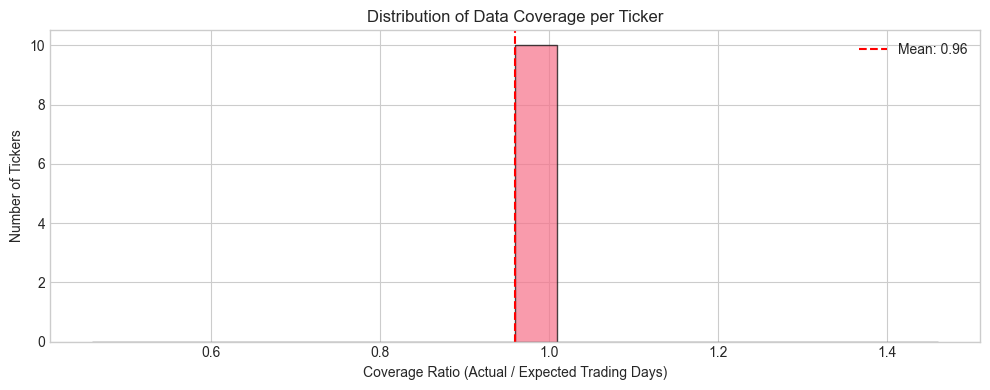

In [10]:
# Data Quality; Ticker-Level Coverage
ticker_summary = df.groupby('Ticker').agg(
    first_date=('Date', 'min'),
    last_date=('Date', 'max'),
    n_records=('Date', 'count'),
).reset_index()

# Expected trading days (roughly 252 / ann)
ticker_summary['years_span'] = (ticker_summary['last_date'] - ticker_summary['first_date']).dt.days / 365.25
ticker_summary['expected_records'] = (ticker_summary['years_span'] * 252).round().astype(int)
ticker_summary['coverage_ratio'] = ticker_summary['n_records'] / ticker_summary['expected_records']

print("Ticker-level coverage summary:")
print(ticker_summary.sort_values('n_records', ascending=False).to_string(index=False))

# Coverage histogram
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ticker_summary['coverage_ratio'].clip(0, 1), bins=20, edgecolor='black', alpha=0.7)
ax.set_xlabel('Coverage Ratio (Actual / Expected Trading Days)')
ax.set_ylabel('Number of Tickers')
ax.set_title('Distribution of Data Coverage per Ticker')
ax.axvline(ticker_summary['coverage_ratio'].mean(), color='red', linestyle='--', label=f'Mean: {ticker_summary["coverage_ratio"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
# descriptive statistics; price and volume
print("=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)

numeric_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
desc = df[numeric_cols].describe().T
desc['skewness'] = df[numeric_cols].skew()
desc['kurtosis'] = df[numeric_cols].kurtosis()
print(desc.round(4))

DESCRIPTIVE STATISTICS
             count          mean           std   min        25%        50%  \
Open       10580.0  2.910186e+03  7.434304e+03  50.0      218.0      471.0   
High       10580.0  2.956912e+03  7.535631e+03  50.0      224.0      486.0   
Low        10580.0  2.864619e+03  7.336597e+03  50.0      212.0      464.0   
Close      10580.0  2.906947e+03  7.430836e+03  50.0      217.5      472.0   
Adj Close  10580.0  2.188978e+03  5.424926e+03  50.0      208.0      462.0   
Volume     10580.0  1.213357e+08  5.899081e+08   0.0  1215950.0  7259900.0   

                    75%           max  skewness  kurtosis  
Open       1.440000e+03  4.535000e+04    3.5898   12.5047  
High       1.470000e+03  4.565000e+04    3.5851   12.4678  
Low        1.410000e+03  4.477500e+04    3.5956   12.5478  
Close      1.436250e+03  4.535000e+04    3.5923   12.5259  
Adj Close  1.349602e+03  3.248295e+04    3.7251   13.0415  
Volume     4.354858e+07  1.519175e+10   10.5942  144.8814  


Prices are heavily right skewed (skewness >> 0); typical for stock prices; suggests log transformation

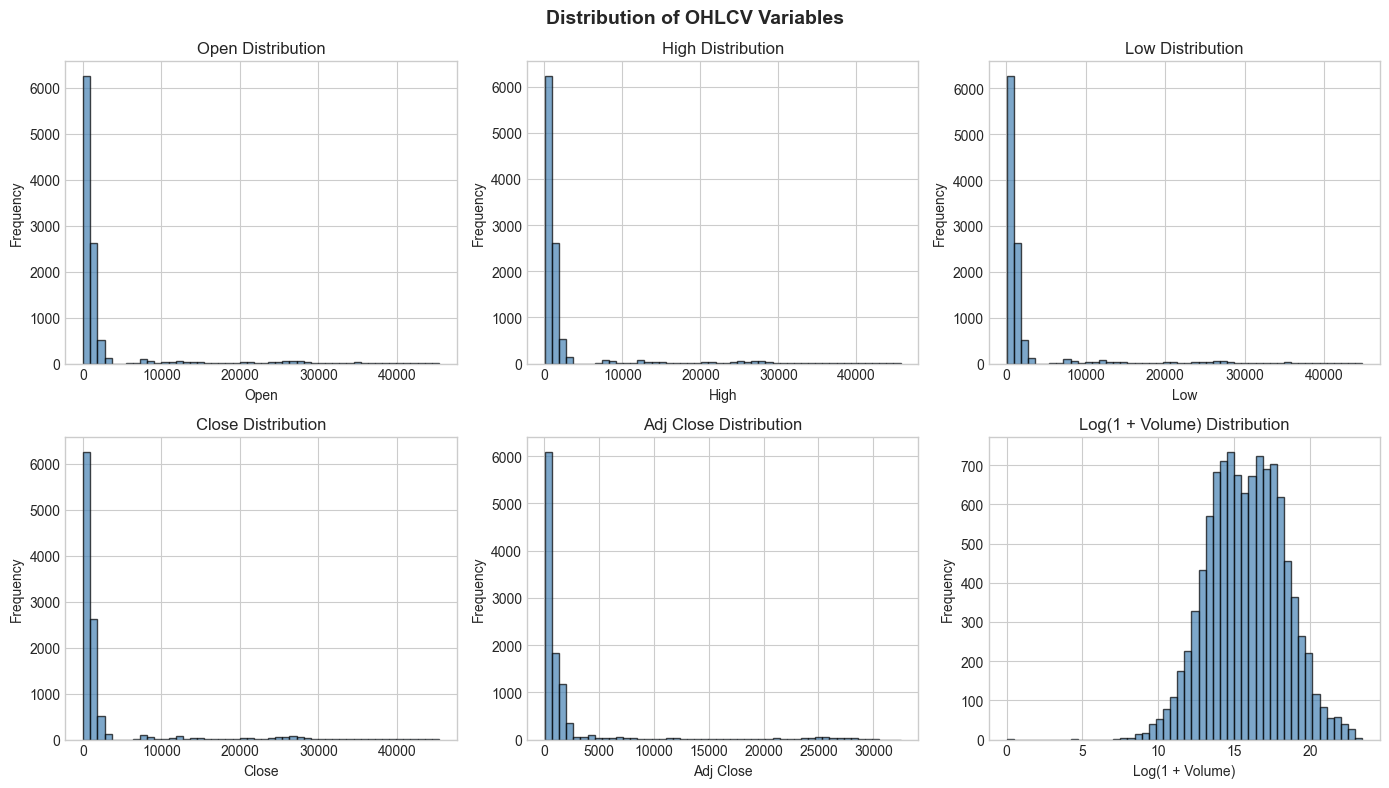

In [12]:
# dist visualizations
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    if col == 'Volume':
        data = np.log1p(df[col])
        ax.hist(data, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        ax.set_title(f'Log(1 + {col}) Distribution')
        ax.set_xlabel(f'Log(1 + {col})')
    else:
        ax.hist(df[col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        ax.set_title(f'{col} Distribution')
        ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.suptitle('Distribution of OHLCV Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

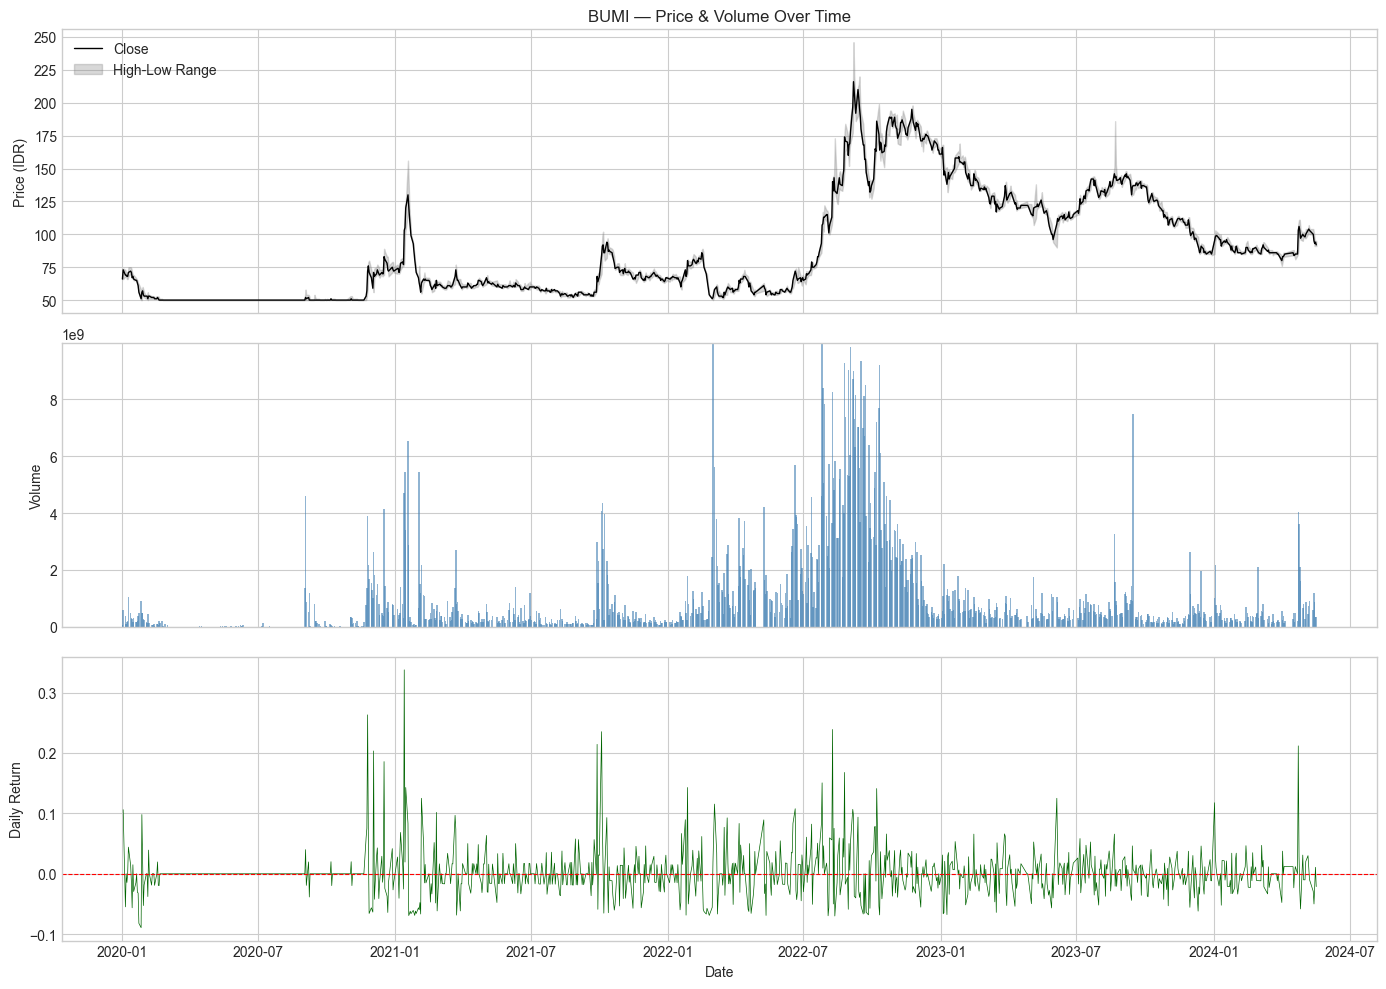


Sample ticker: BUMI
Trading days: 1,058
Date range: 2020-01-02 to 2024-05-17


In [13]:
# Time Series Visualization w/ Sample Ticker
sample_ticker = selected_tickers[0]
sample_df = df[df['Ticker'] == sample_ticker].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(sample_df['Date'], sample_df['Close'], label='Close', color='black', linewidth=1)
axes[0].fill_between(sample_df['Date'], sample_df['Low'], sample_df['High'], alpha=0.3, color='gray', label='High-Low Range')
axes[0].set_ylabel('Price (IDR)')
axes[0].set_title(f'{sample_ticker} — Price & Volume Over Time')
axes[0].legend(loc='upper left')

axes[1].bar(sample_df['Date'], sample_df['Volume'], width=2, color='steelblue', alpha=0.6)
axes[1].set_ylabel('Volume')
axes[1].set_ylim(0, sample_df['Volume'].quantile(0.99) * 1.2)

sample_df['Daily_Return'] = sample_df['Close'].pct_change()
axes[2].plot(sample_df['Date'], sample_df['Daily_Return'], color='darkgreen', linewidth=0.5)
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=0.8)
axes[2].set_ylabel('Daily Return')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

print(f"\nSample ticker: {sample_ticker}")
print(f"Trading days: {len(sample_df):,}")
print(f"Date range: {sample_df['Date'].min().date()} to {sample_df['Date'].max().date()}")

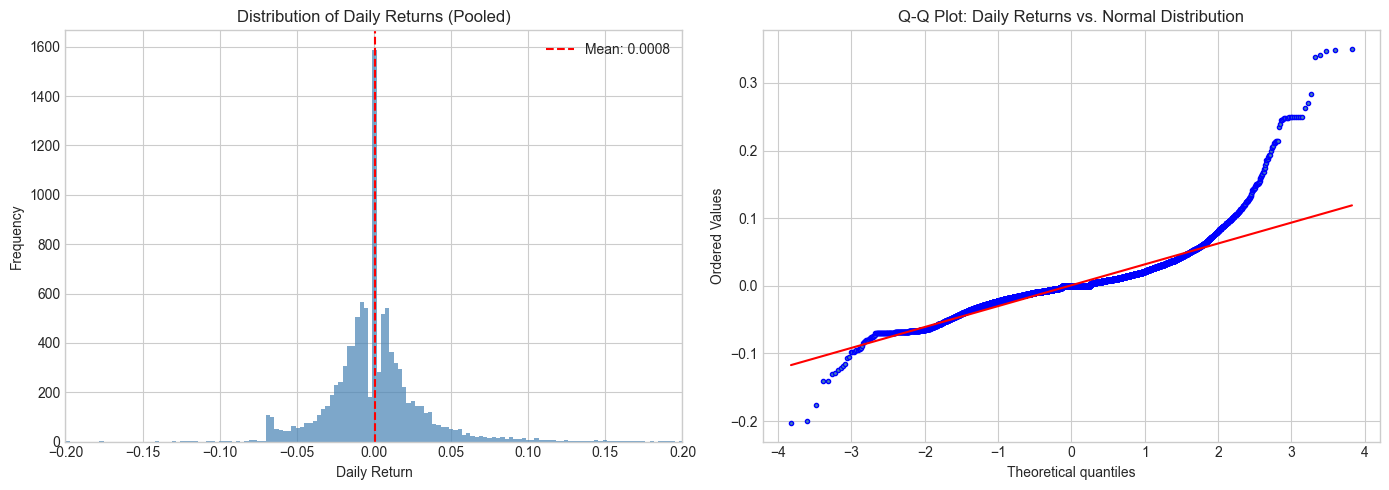


Returns Statistics:
  Mean:     0.000787
  Std Dev:  0.033591
  Skewness: 2.0934
  Kurtosis: 14.7814
  Min:      -0.2028
  Max:      0.3500


In [14]:
# Returns - dist and stationary
df['Daily_Return'] = df.groupby('Ticker')['Close'].pct_change()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

returns = df['Daily_Return'].dropna()
axes[0].hist(returns, bins=200, edgecolor='none', alpha=0.7, color='steelblue')
axes[0].set_xlim(-0.2, 0.2)
axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Daily Returns (Pooled)')
axes[0].axvline(returns.mean(), color='red', linestyle='--', label=f'Mean: {returns.mean():.4f}')
axes[0].legend()

stats.probplot(returns, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: Daily Returns vs. Normal Distribution')
axes[1].get_lines()[0].set_markerfacecolor('steelblue')
axes[1].get_lines()[0].set_markersize(3)

plt.tight_layout()
plt.show()

print("\nReturns Statistics:")
print(f"  Mean:     {returns.mean():.6f}")
print(f"  Std Dev:  {returns.std():.6f}")
print(f"  Skewness: {returns.skew():.4f}")
print(f"  Kurtosis: {returns.kurtosis():.4f}")
print(f"  Min:      {returns.min():.4f}")
print(f"  Max:      {returns.max():.4f}")

Returns show fat tails --> high kurtosis; slight negative skewness

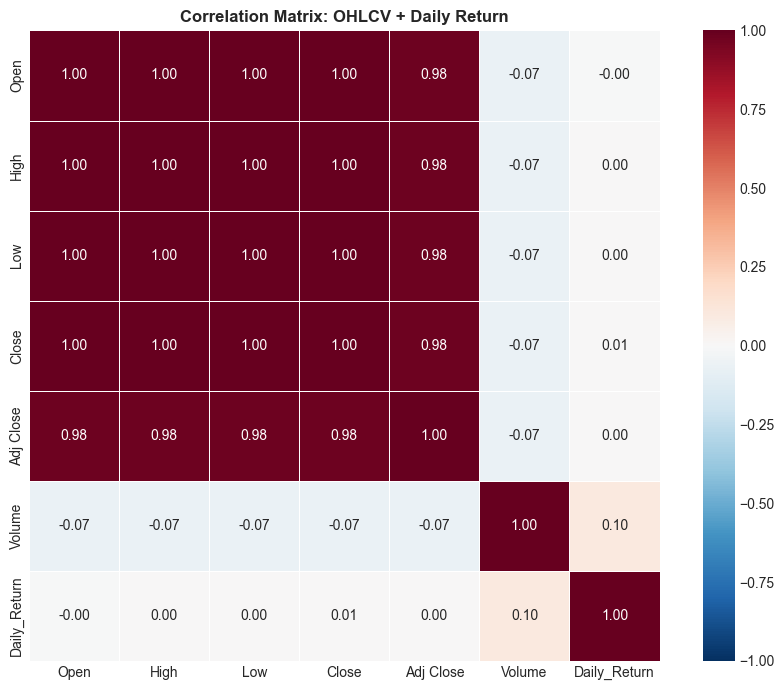

In [15]:
# Correlation — OHLCV Relationships
corr_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Daily_Return']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix: OHLCV + Daily Return', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

OHLC are highly correlated; could imply the use of derived features

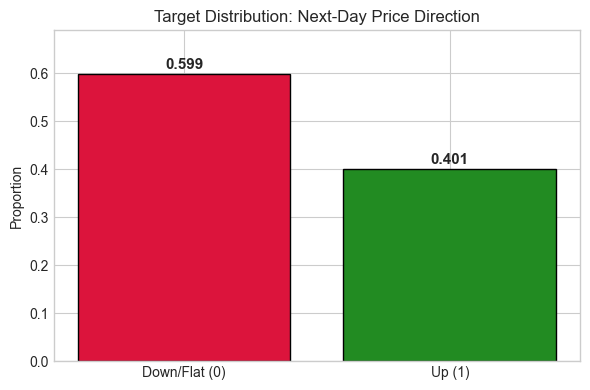


Target distribution:
  Down/Flat (0): 0.5991 (59.9%)
  Up (1):        0.4009 (40.1%)


In [16]:
# Target var (Next-Day Direction)
df['Target'] = df.groupby('Ticker')['Close'].shift(-1) > df['Close']
df['Target'] = df['Target'].astype(int)

target_dist = df['Target'].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Down/Flat (0)', 'Up (1)'], target_dist.values, color=['crimson', 'forestgreen'], edgecolor='black')
ax.set_ylabel('Proportion')
ax.set_title('Target Distribution: Next-Day Price Direction')
ax.set_ylim(0, target_dist.max() * 1.15)
for bar, val in zip(bars, target_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTarget distribution:")
print(f"  Down/Flat (0): {target_dist[0]:.4f} ({target_dist[0]*100:.1f}%)")
print(f"  Up (1):        {target_dist[1]:.4f} ({target_dist[1]*100:.1f}%)")


df = df.drop(columns=['Target'])

Target is moderately imbalanced 63/37
Down days outnumber up days (lol); majority class is 0
Consider class weights or stratified metrics.

In [17]:
# Trading day gap analysis
def analyze_gaps(group):
    group = group.sort_values('Date')
    gaps = group['Date'].diff().dt.days
    return pd.Series({
        'max_gap_days': gaps.max(),
        'avg_gap_days': gaps.mean(),
        'n_gaps_over_5': (gaps > 5).sum()
    })

gap_stats = df.groupby('Ticker').apply(analyze_gaps)

print("Trading Day Gap Statistics per Ticker:")
print(gap_stats.round(2))

Trading Day Gap Statistics per Ticker:
        max_gap_days  avg_gap_days  n_gaps_over_5
Ticker                                           
BUMI            11.0          1.51            7.0
ELSA            11.0          1.51            7.0
HRUM            11.0          1.51            7.0
INDY            11.0          1.51            7.0
ITMG            11.0          1.51            7.0
LUCK            11.0          1.51            7.0
MBSS            11.0          1.51            7.0
PGAS            11.0          1.51            7.0
PSSI            11.0          1.51            7.0
PTSN            11.0          1.51            7.0


---

## End of Phase 2: EDA Summary

Before proceeding to **Phase 3 (Preprocessing)**, here are the key findings:

| Aspect | Finding | Implication |
|--------|---------|-------------|
| **Dataset scale** | ~millions of rows across hundreds of tickers (2020–2024) | Need memory-efficient chunked processing |
| **Missing data** | (see Cell 7) | Decide: drop, forward-fill, or interpolate |
| **Duplicates** | (see Cell 7) | Remove if any Date+Ticker duplicates exist |
| **Price skewness** | Heavily right-skewed | Use returns/ratios instead of raw prices |
| **Returns distribution** | Fat tails, slight negative skew | Rolling volatility is a valuable feature |
| **OHLC correlation** | >0.95 among price columns | Engineer uncorrelated features (ranges, returns) |
| **Target balance** | ~50/50 up/down | Accuracy is a valid primary metric |
| **Trading gaps** | Some tickers have extended gaps | Need careful handling for rolling window features |

### Action Items Before Phase 3:

1. **Obtain sector classification data** — The primary dataset lacks IDX-IC sector info. Download from one of:
   - [IDX Official Stock List](https://www.idx.co.id/en/market-data/stocks-data/stock-list/) (Download button → Excel with sector column)
   - [Kaggle: Indonesian Public Companies](https://www.kaggle.com/datasets/zororaka/indonesian-public-companies)
   - Join on `Ticker` column and document how unmatched tickers are handled.

2. **Select 2–3 IDX-IC sectors** — Per GOAL.md, choose sectors with ≤100 stocks total, roughly balanced across sectors. Document your criteria.

3. **Decide on preprocessing strategy:**
   - Minimum history threshold per ticker (e.g., 2+ years of data)?
   - How to handle trading gaps >5 days?
   - Feature lookback windows: 5-day, 10-day, 20-day, or multiple?
   - Adjusted Close vs Close for feature engineering?

4. **Define temporal split dates** — Train/validation/test must preserve time order:
   - Example: Train 2020-01 to 2022-12, Validation 2023-01 to 2023-12, Test 2024-01 to 2024-12

**Please review the EDA outputs above, obtain sector data, and let me know your preferences before I proceed to Phase 3.**

---

## Phase 3: Data Preparation — Sector Selection & Cleaned OHLCV Export


In [18]:
# Load and combine by sector
# Use local IDX-IC sector CSV files when available. The embedded fallback keeps
# this notebook runnable in Colab when only the notebook itself was uploaded.

import glob

SECTOR_DIR = os.path.join('Dataset', 'stock-list-per-sector')
sector_files = glob.glob(os.path.join(SECTOR_DIR, '*.csv'))

sector_dfs = []
for f in sorted(sector_files):
    basename = os.path.basename(f)
    # filename format: "Stock List  - {Sector} - YYYYMMDD.csv"
    sector_name = basename.split(' - ')[1].strip()
    df_s = pd.read_csv(f)
    df_s['Sector'] = sector_name
    sector_dfs.append(df_s[['Code', 'Sector']])

if sector_dfs:
    sector_df = pd.concat(sector_dfs, ignore_index=True)
    sector_df = sector_df.rename(columns={'Code': 'Ticker'})
else:
    FALLBACK_SECTOR_TICKERS = {
        'Energy': [
            'ABMM', 'AKRA', 'APEX', 'ARII', 'ARTI', 'BBRM', 'BIPI', 'BSSR',
            'BULL', 'BUMI', 'BYAN', 'CANI', 'CNKO', 'DEWA', 'DOID', 'DSSA',
            'ELSA', 'ENRG', 'GEMS', 'GTBO', 'HITS', 'HRUM', 'IATA', 'INDY',
            'ITMA', 'ITMG', 'KKGI', 'KOPI', 'LEAD', 'MBAP', 'MBSS', 'MEDC',
            'MTFN', 'MYOH', 'PGAS', 'PKPK', 'PTBA', 'PTIS', 'PTRO', 'RAJA',
            'RIGS', 'RUIS', 'SMMT', 'SMRU', 'SOCI', 'SUGI', 'TOBA', 'TPMA',
            'TRAM', 'WINS', 'SHIP', 'TAMU', 'FIRE', 'PSSI', 'DWGL', 'BOSS',
            'JSKY', 'INPS', 'TCPI', 'SURE', 'WOWS', 'TEBE', 'SGER', 'UNIQ',
            'MCOL', 'GTSI', 'RMKE', 'BSML', 'ADMR', 'SEMA', 'SICO', 'COAL',
            'SUNI', 'CBRE', 'HILL', 'CUAN', 'MAHA', 'RMKO', 'HUMI', 'RGAS',
            'ALII', 'MKAP', 'ATLA', 'BOAT', 'AADI', 'RATU', 'PSAT', 'BESS',
            'CGAS', 'ADRO', 'AIMS',
        ],
        'Technology': [
            'ATIC', 'EMTK', 'KREN', 'LMAS', 'MLPT', 'MTDL', 'PTSN', 'SKYB',
            'KIOS', 'MCAS', 'NFCX', 'DIVA', 'LUCK', 'ENVY', 'HDIT', 'TFAS',
            'DMMX', 'GLVA', 'PGJO', 'CASH', 'TECH', 'EDGE', 'ZYRX', 'UVCR',
            'BUKA', 'RUNS', 'WGSH', 'WIRG', 'GOTO', 'AXIO', 'BELI', 'NINE',
            'ELIT', 'IRSX', 'CHIP', 'TRON', 'JATI', 'CYBR', 'IOTF', 'MSTI',
            'TOSK', 'MPIX', 'AREA', 'MENN', 'AWAN', 'WIFI', 'DCII',
        ],
    }
    sector_df = pd.DataFrame(
        [
            (ticker, sector)
            for sector, tickers in FALLBACK_SECTOR_TICKERS.items()
            for ticker in tickers
        ],
        columns=['Ticker', 'Sector'],
    )
    print('Sector CSV folder not found; using embedded Energy/Technology mapping.')

# Cross-reference with tickers present in the OHLCV dataset.
# unique_tickers is the ticker set created during the scale overview.
sector_df = sector_df[sector_df['Ticker'].isin(unique_tickers)].copy()

print(f"Sector files loaded:          {len(sector_files)}")
print(f"Total sector-ticker entries:  {len(sector_df):,}")
print(f"Unique tickers matched:       {sector_df['Ticker'].nunique():,}")
print(f"Unique sectors:               {sector_df['Sector'].nunique()}")
print(f"\nTickers in OHLCV data but NOT in sector list: "
      f"{len(unique_tickers - set(sector_df['Ticker'])):,}")


Sector files loaded:          10
Total sector-ticker entries:  130
Unique tickers matched:       130
Unique sectors:               2

Tickers in OHLCV data but NOT in sector list: 0


In [19]:
sector_counts = sector_df['Sector'].value_counts().sort_values(ascending=False)

print("Sectors with active tickers in 2020-2024 OHLCV data:")
print("-" * 55)
for sector, count in sector_counts.items():
    bar = '#' * (count // 5)
    print(f"  {sector:<30} {count:>4} stocks  {bar}")

# --- select your sectors here ---
SELECTED_SECTORS = ['Energy', 'Technology']

selected_mask = sector_df['Sector'].isin(SELECTED_SECTORS)
SELECTED_MODEL_TICKERS = sector_df[selected_mask]['Ticker'].tolist()

print(f"\nSelected sectors: {SELECTED_SECTORS}")
print(f"Total stocks in selected sectors: {len(SELECTED_MODEL_TICKERS)}")
for s in SELECTED_SECTORS:
    n = sector_df[sector_df['Sector'] == s].shape[0]
    print(f"  {s}: {n} stocks")


Sectors with active tickers in 2020-2024 OHLCV data:
-------------------------------------------------------
  Energy                           83 stocks  ################
  Technology                       47 stocks  #########



Selected sectors: ['Energy', 'Technology']
Total stocks in selected sectors: 130
  Energy: 83 stocks
  Technology: 47 stocks


In [20]:
# Remove Suspended Stocks from Selected Tickers
from collections import defaultdict

print(f"Before suspended filter: {len(SELECTED_MODEL_TICKERS)} tickers")
print("Checking Close price quality on selected tickers...")

close_vals = defaultdict(list)
for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE,
                         usecols=['Date', 'Ticker', 'Close']):
    chunk['Date'] = pd.to_datetime(chunk['Date'])
    mask = (chunk['Date'] >= START_DATE) & (chunk['Date'] <= END_DATE)
    mask &= chunk['Ticker'].isin(SELECTED_MODEL_TICKERS)
    chunk = chunk[mask]
    if len(chunk) == 0:
        continue
    for ticker in chunk['Ticker'].unique():
        sub = chunk[chunk['Ticker'] == ticker]
        close_vals[ticker].append(sub['Close'].values)

suspended_in_selection = []
for ticker in SELECTED_MODEL_TICKERS:
    if ticker in close_vals:
        all_close = np.concatenate(close_vals[ticker])
        if np.nanstd(all_close) == 0:
            suspended_in_selection.append(ticker)
    else:
        suspended_in_selection.append(ticker)  # no data at all

if suspended_in_selection:
    print(f"Removing {len(suspended_in_selection)} suspended: "
          f"{suspended_in_selection}")
    SELECTED_MODEL_TICKERS = [t for t in SELECTED_MODEL_TICKERS
                              if t not in suspended_in_selection]
else:
    print("No suspended tickers found.")

print(f"After suspended filter:  {len(SELECTED_MODEL_TICKERS)} tickers")
print(f"Final tickers: {SELECTED_MODEL_TICKERS}")


Before suspended filter: 130 tickers
Checking Close price quality on selected tickers...


No suspended tickers found.
After suspended filter:  130 tickers
Final tickers: ['ABMM', 'AKRA', 'APEX', 'ARII', 'ARTI', 'BBRM', 'BIPI', 'BSSR', 'BULL', 'BUMI', 'BYAN', 'CANI', 'CNKO', 'DEWA', 'DOID', 'DSSA', 'ELSA', 'ENRG', 'GEMS', 'GTBO', 'HITS', 'HRUM', 'IATA', 'INDY', 'ITMA', 'ITMG', 'KKGI', 'KOPI', 'LEAD', 'MBAP', 'MBSS', 'MEDC', 'MYOH', 'PGAS', 'PKPK', 'PTBA', 'PTIS', 'PTRO', 'RAJA', 'RIGS', 'RUIS', 'SMMT', 'SOCI', 'TOBA', 'TPMA', 'WINS', 'SHIP', 'TAMU', 'FIRE', 'PSSI', 'DWGL', 'BOSS', 'JSKY', 'INPS', 'TCPI', 'SURE', 'WOWS', 'TEBE', 'SGER', 'UNIQ', 'MCOL', 'GTSI', 'RMKE', 'BSML', 'ADMR', 'SEMA', 'SICO', 'COAL', 'SUNI', 'CBRE', 'HILL', 'CUAN', 'MAHA', 'RMKO', 'HUMI', 'RGAS', 'ALII', 'MKAP', 'ATLA', 'BESS', 'CGAS', 'ADRO', 'AIMS', 'ATIC', 'EMTK', 'KREN', 'LMAS', 'MLPT', 'MTDL', 'PTSN', 'SKYB', 'KIOS', 'MCAS', 'NFCX', 'DIVA', 'LUCK', 'ENVY', 'HDIT', 'TFAS', 'DMMX', 'GLVA', 'PGJO', 'CASH', 'TECH', 'EDGE', 'ZYRX', 'UVCR', 'BUKA', 'RUNS', 'WGSH', 'WIRG', 'GOTO', 'AXIO', 'BELI', 'NINE',

### Survivorship Bias Handling

The tickers in this analysis pass through a **three-layer filter** that
ensures zero survivorship bias for the intended use case (retail investor
decision support in the current Indonesian equity market):

| Layer | Filter | What it removes |
|-------|--------|-----------------|
| 1 | Current IDX stock list (sector CSVs, 2026-05-19) | Stocks delisted before today |
| 2 | Cross-reference with OHLCV data (2020-2024) | Stocks that IPO'd after 2024 (no historical data) |
| 3 | Suspended filter (close_std == 0) | Listed but untradeable stocks (35 flagged) |

**Result**: Every ticker in the output is currently listed on the IDX and
actively traded. An investor today can buy every stock in this dataset.

> Note: This approach intentionally excludes stocks that were actively traded
> during 2020-2024 but delisted before 2026. For a historical backtesting
> framework, you would do the opposite (include delisted stocks to avoid
> survivorship bias in backtests). For this project's goal of supporting
> current investment decisions, the survivor set is the correct one.


In [21]:
# Load Full OHLCV Data for Selected Sectors
print(f"Loading full OHLCV data for {len(SELECTED_MODEL_TICKERS)} tickers...")

dfs_all = []
for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE):
    chunk['Date'] = pd.to_datetime(chunk['Date'])
    date_mask = (chunk['Date'] >= START_DATE) & (chunk['Date'] <= END_DATE)
    ticker_mask = chunk['Ticker'].isin(SELECTED_MODEL_TICKERS)
    chunk = chunk[date_mask & ticker_mask]
    if len(chunk) == 0:
        continue
    dfs_all.append(chunk)

df_model = pd.concat(dfs_all, ignore_index=True)
df_model = df_model.sort_values(['Ticker', 'Date']).reset_index(drop=True)

# Attach sector label to each row
ticker_to_sector = dict(zip(sector_df['Ticker'], sector_df['Sector']))
df_model['sector'] = df_model['Ticker'].map(ticker_to_sector)

print(f"Loaded {len(df_model):,} rows for {df_model['Ticker'].nunique()} tickers")
print(f"Date range: {df_model['Date'].min().date()} to {df_model['Date'].max().date()}")
print(f"Sectors: {df_model['sector'].unique()}")
print(f"\nRecords per ticker: min={df_model.groupby('Ticker').size().min()}, "
      f"median={df_model.groupby('Ticker').size().median():.0f}, "
      f"max={df_model.groupby('Ticker').size().max()}")


Loading full OHLCV data for 130 tickers...


Loaded 95,932 rows for 130 tickers
Date range: 2020-01-02 to 2024-05-17
Sectors: <ArrowStringArray>
['Energy', 'Technology']
Length: 2, dtype: str

Records per ticker: min=21, median=958, max=1058


In [22]:
# Data Cleaning
print(f"Before cleaning: {len(df_model):,} rows")

# Forward-fill missing OHLCV within each ticker (limit=3 to avoid over-filling gaps)
ohlcv_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
df_model[ohlcv_cols] = df_model.groupby('Ticker')[ohlcv_cols].transform(
    lambda g: g.ffill(limit=3)
)

# Drop rows where Close is still NaN after forward-fill
before = len(df_model)
df_model = df_model.dropna(subset=['Close'])
print(f"Dropped {before - len(df_model):,} rows with NaN Close")

# Remove non-trading days (zero volume AND flat OHLC)
df_model['_flat'] = (df_model['High'] == df_model['Low']) & (df_model['Volume'] == 0)
n_flat = df_model['_flat'].sum()
df_model = df_model[~df_model['_flat']].drop(columns=['_flat'])
print(f"Removed {n_flat:,} zero-volume flat-price rows")

print(f"After cleaning: {len(df_model):,} rows")
print(f"Missing values remaining:")
print(df_model[ohlcv_cols].isnull().sum())


Before cleaning: 95,932 rows
Dropped 0 rows with NaN Close


Removed 0 zero-volume flat-price rows
After cleaning: 95,932 rows
Missing values remaining:


Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [23]:
# Preview cleaned data before export
print(f"Cleaned data shape: {df_model.shape[0]:,} rows x {df_model.shape[1]} columns")
print(f"Columns: {list(df_model.columns)}")
print(f"Data types:")
print(df_model.dtypes)
print(f"Descriptive statistics (numeric columns):")
display(df_model.describe())


Cleaned data shape: 95,932 rows x 9 columns
Columns: ['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'sector']
Data types:
Date         datetime64[us]
Ticker                  str
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume              float64
sector                  str
dtype: object
Descriptive statistics (numeric columns):


,Date,Open,High,Low,Close,Adj Close,Volume
count,95932,95932.000000,95932.000000,95932.000000,95932.000000,95932.000000,9.593200e+04
mean,2022-05-23 19:55:30.409039,1768.183191,1802.005910,1737.301416,1770.644404,1624.793873,5.709491e+07
min,2020-01-02 00:00:00,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000e+00
25%,2021-05-20 00:00:00,141.000000,146.000000,137.000000,141.000000,139.000000,1.027000e+05
50%,2022-06-30 00:00:00,345.396820,354.000000,336.000000,344.000000,330.000000,1.640800e+06
75%,2023-06-26 00:00:00,1190.000000,1215.000000,1160.000000,1190.000000,1064.818604,1.673460e+07
max,2024-05-17 00:00:00,148000.000000,163000.000000,147700.000000,147975.000000,147975.000000,6.601081e+10
std,NaN,5749.069504,5849.699652,5687.559082,5779.526332,5495.453819,4.784653e+08


---

## End of Phase 3

The cleaned OHLCV dataset is exported below.


In [24]:
#export as parquet
import os as _os

OUTPUT_DIR = os.path.join("Dataset", "cleaned")
_os.makedirs(OUTPUT_DIR, exist_ok=True)

export_cols = ["Date", "Ticker", "Open", "High", "Low", "Close", "Adj Close", "Volume"]
total_rows = 0
sector_sizes = {}

for sector in sorted(df_model["sector"].unique()):
    mask = df_model["sector"] == sector
    sector_df = df_model[mask][export_cols].copy()
    sector_name = sector.lower().replace(" ", "_")
    path = os.path.join(OUTPUT_DIR, f"{sector_name}.parquet")

    sector_df.to_parquet(path, index=False, compression="snappy")

    size_mb = _os.path.getsize(path) / (1024**2)
    n_tickers = sector_df["Ticker"].nunique()
    sector_sizes[sector] = {"rows": len(sector_df), "tickers": n_tickers, "size_mb": size_mb}
    total_rows += len(sector_df)

    print(f"  {sector:<20} {n_tickers:>4} tickers  {len(sector_df):>8,} rows  {size_mb:>6.1f} MB  → {sector_name}.parquet")

print(f"Total: {total_rows:,} rows across {len(sector_sizes)} sectors")


  Energy                 83 tickers    66,885 rows     1.1 MB  → energy.parquet
  Technology             47 tickers    29,047 rows     0.5 MB  → technology.parquet
Total: 95,932 rows across 2 sectors


In [25]:
print(f"Tickers:           {df_model['Ticker'].nunique()}")
print(f"Total rows:        {len(df_model):,}")
print(f"Date range:        {df_model['Date'].min().date()} to {df_model['Date'].max().date()}")
print(f"Sectors:           {list(df_model['sector'].unique())}")
print("Sector distribution:")
print(df_model['sector'].value_counts())
print(f"Parquet files in {OUTPUT_DIR}:")
for f in sorted(_os.listdir(OUTPUT_DIR)):
    if f.endswith(".parquet"):
        fp = os.path.join(OUTPUT_DIR, f)
        mb = _os.path.getsize(fp) / (1024**2)
        print(f"  {f:<30} {mb:>6.1f} MB")
print(f"Rows per ticker: min={df_model.groupby('Ticker').size().min()}, "
      f"median={df_model.groupby('Ticker').size().median():.0f}, "
      f"max={df_model.groupby('Ticker').size().max()}")
print("Missing values:")
print(df_model.isnull().sum())


Tickers:           130
Total rows:        95,932
Date range:        2020-01-02 to 2024-05-17
Sectors:           ['Energy', 'Technology']
Sector distribution:
sector
Energy        66885
Technology    29047
Name: count, dtype: int64
Parquet files in Dataset\cleaned:
  energy.parquet                    1.1 MB
  technology.parquet                0.5 MB
Rows per ticker: min=21, median=958, max=1058
Missing values:
Date         0
Ticker       0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
sector       0
dtype: int64


---
# Part 2: Feature Engineering and Processed Dataset Construction

Source notebook: `02_feature_engineering_modeling.ipynb`. Covers derived features, lag features, rolling windows, sector-relative features, calendar features, target construction, validation checks, NaN removal, and processed parquet export.

# IDX Next-Day Price Direction Prediction
## Phase 1: Feature Engineering & Modeling Dataset Construction

**Sections 1–9**: Load cleaned data -> engineer features -> create target -> drop NaN -> export pre-split dataset.

Preventing leakage: All operations up to Section 9 are per-ticker or per-date and backward-looking only. 

## We left off week 1 (01_EDA_Cleaning.ipynb) with:
**Input:** `eren2222/complete-indonesia-stock-exchange-idx-2000-2024` from Kaggle, which contains JCI stock data from 2000-2024.

**Key findings from EDA:**
- OHLC columns correlated >0.95; raw prices introduce multicollinearity without signal
- Returns are fat-tailed (high kurtosis), slightly negative skew
- Target class balance: ~63% down days / ~37% up days
- Many instances of delisted stocks creating "flat" price action, this was handled by only taking stocks whose tickers are listed in the IDX website

**Sector selection:** Energy (87 tickers) + Technology (47 tickers). Contrasting dynamics: commodity-driven vs. growth/volatility. 4 suspended tickers removed, leaving 130.

**Data cleaning:**
- Forward-filled OHLCV gaps (limit=3) per ticker
- Removed zero-volume flat-price rows (likely non-trading days): 9,304 rows dropped
- Result: 95,932 rows, 0 missing values, 0 duplicates

**Output:** `Dataset/cleaned/energy.parquet` and `technology.parquet`

## This week (week 2):
### Data Preparation & Feature Engineering

**Principle:** Encode temporal context into a flat feature vector per row. The model sees one (ticker, day) at a time; all memory of the past must be explicit.

**Feature categories:**

- **Base derived (7):** daily_return, log_return, high_low_spread, close_open_gap, price_position, volume_change, log_volume
- **Lag features (30):** 5 base cols * lags [1,2,3,5,10,20]. Validated with ACF/PACF which indicated autocorrelation at short lags, PACF cutoff ~5-10
- **Rolling window (29):** 4 windows [5,10,20,50] * 7 stat types (price_vs_ma, volatility, volume_ratio, volume_std, momentum, dist_from_high, dist_from_low) + autocorr_20d
- **Cross-sectional (8):** sector_avg_return (ex-self), sector_return_dispersion, relative_strength, sector_pos_frac, sector_total_volume, rel_strength_ma5/20, sector_vol_regime
- **Calendar (3):** day_of_week, month, quarter

**Design constraints enforced:**
- Scale invariant features only (ratios, returns) for cross ticker comparability
- All groupby + shift/rolling operations per ticker; so no cross ticker leakage
- Cross sectional sector averages exclude self; no self comparison

**Validation:**
- Rolling MA overlay: `price_vs_ma20` matches manual Close/MA20-1 to 6 decimal places
- Lag shift check: correlation(`daily_return(t)`, `daily_return_lag1(t+1)`) = 1.0
- Target verification: all rows checked that t+1 matches its assigned class value
- Inf values (pct_change div-by-zero on AKRA, ITMG, RIGS): replaced with NaN, dropped in Section 8

**Output:** `Dataset/processed/energy.parquet` and `technology.parquet`. 77 features + target.

## Important Note:
This still has too many features, next IPYNB will attempt to find which features actually matter and prune the rest.

In [26]:
import os
import sys
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = os.path.join('Dataset', 'cleaned')
OUTPUT_DIR = os.path.join('Dataset', 'processed')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Python: {sys.version.split()[0]}  |  Pandas: {pd.__version__}  |  NumPy: {np.__version__}")

Timestamp: 2026-05-30 20:13:12


Python: 3.12.5  |  Pandas: 3.0.1  |  NumPy: 2.4.3


---
## Section 1: Setup & Data Loading

In [27]:
energy = pd.read_parquet(os.path.join(DATA_DIR, 'energy.parquet'))
energy['sector'] = 'Energy'

technology = pd.read_parquet(os.path.join(DATA_DIR, 'technology.parquet'))
technology['sector'] = 'Technology'

df = pd.concat([energy, technology], ignore_index=True)
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

print(f"Total rows:     {len(df):,}")
print(f"Unique tickers: {df['Ticker'].nunique()}")
print(f"Date range:     {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"\nSector distribution:")
print(df['sector'].value_counts())
print(f"\nColumns: {list(df.columns)}")
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nRows per ticker — min: {df.groupby('Ticker').size().min()}, "
      f"median: {df.groupby('Ticker').size().median():.0f}, "
      f"max: {df.groupby('Ticker').size().max()}")

Total rows:     95,932
Unique tickers: 130
Date range:     2020-01-02 to 2024-05-17

Sector distribution:
sector
Energy        66885
Technology    29047
Name: count, dtype: int64

Columns: ['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'sector']

Missing values:
Date         0
Ticker       0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
sector       0
dtype: int64

Rows per ticker — min: 21, median: 958, max: 1058


---
## Section 2: Base Derived Features

Per-ticker features: intraday dynamics and daily changes. All use Adj Close for returns and raw OHLC for intraday ratios (scale-invariant).

Scale invariant: A feature's value doesn't depend on the absolute price level of the stock, but instead uses ratios.

In [28]:
def add_base_features(df):
    """Add per-ticker derived features. All backward-looking by construction."""
    df = df.copy()

    g = df.groupby('Ticker')

    # returns - Adj Close avoids split/dividend halts
    df['daily_return'] = g['Adj Close'].pct_change()
    df['log_return'] = np.log(df['Adj Close'] / g['Adj Close'].shift(1))

    # intraday features (scale-invariant ratios-- think of this like normalization)
    df['high_low_spread'] = (df['High'] - df['Low']) / df['Close']
    df['close_open_gap'] = (df['Close'] - df['Open']) / df['Open']

    # price position within daily range (0 = low, 1 = high)
    hl_range = df['High'] - df['Low']
    df['price_position'] = np.where(
        hl_range > 0,
        (df['Close'] - df['Low']) / hl_range,
        0.5  # fill when High == Low (rare, flat day)
    )

    # volume
    df['volume_change'] = g['Volume'].pct_change()
    df['log_volume'] = np.log1p(df['Volume'])

    return df

In [29]:
df = add_base_features(df)

print("features added:")
base_cols = ['daily_return', 'log_return', 'high_low_spread',
             'close_open_gap', 'price_position', 'volume_change', 'log_volume']
print(df[base_cols].describe().round(4))

features added:


       daily_return  log_return  high_low_spread  close_open_gap  \
count    95802.0000  95802.0000       95932.0000      95932.0000   
mean         0.0007     -0.0001           0.0507             inf   
std          0.0430      0.0415           0.0480             NaN   
min         -0.3462     -0.4249           0.0000         -0.3824   
25%         -0.0159     -0.0160           0.0208         -0.0170   
50%          0.0000      0.0000           0.0390          0.0000   
75%          0.0105      0.0105           0.0672          0.0103   
max          0.5000      0.4055           0.7549             inf   

       price_position  volume_change  log_volume  
count      95932.0000     95802.0000  95932.0000  
mean           0.4597            inf     13.9356  
std            0.3241            NaN      3.5423  
min            0.0000        -1.0000      0.0000  
25%            0.1890        -0.4682     11.5396  
50%            0.5000        -0.0360     14.3107  
75%            0.7000         

---
## Section 3: Lag Features

For each key derived feature, create lagged versions at [1, 2, 3, 5, 10, 20] trading days. `groupby('Ticker') + shift()` ensures no cross-ticker leakage.

### Definition: Lag features: 
The model can't look into the past on its own, it "sees" one row at a time as a flat vector; we need to encode past information as a feature to give the model learn relationships between $t_0, ..., t_n$ and $t_{n+1}$

In [30]:
LAG_COLS = ['daily_return', 'volume_change', 'high_low_spread',
            'close_open_gap', 'price_position']
LAG_DAYS = [1, 2, 3, 5, 10, 20]

lagged_features = []
for col in LAG_COLS:
    for lag in LAG_DAYS:
        name = f'{col}_lag{lag}'
        df[name] = df.groupby('Ticker')[col].shift(lag)
        lagged_features.append(name)

In [31]:
print(f"Lag features created: {len(lagged_features)}")
print(f"  Source columns: {LAG_COLS}")
print(f"  Lag windows:    {LAG_DAYS}")
print(f"  Total:          {len(LAG_COLS)} × {len(LAG_DAYS)} = {len(lagged_features)}")

Lag features created: 30
  Source columns: ['daily_return', 'volume_change', 'high_low_spread', 'close_open_gap', 'price_position']
  Lag windows:    [1, 2, 3, 5, 10, 20]
  Total:          5 × 6 = 30


---
### ACF & PACF: verify there is temporal structure worth modeling?

**ACF (Autocorrelation Function):** Correlation between `daily_return(t)` and `daily_return(t-k)`. A spike at lag k means today's return is correlated with the return k days ago, including chain effects through lags.

**PACF (Partial Autocorrelation Function):** Direct correlation after removing intermediate lags. A spike at lag k means lag k carries unique predictive signal beyond what lags $1, …,k-1$ already capture.

How to read plots:
- Bars past the blue band = statistically significant
- ACF decays slowly -> trend/momentum present. ACF near zero everywhere -> returns are close to white noise (hard to predict)
- PACF cuts off after lag N -> only ~N lags carry unique signal. If PACF cuts off at lag ~5, our lags 10–20 add diminishing returns, etc.

Plots: pooled sector-level ACF/PACF (avg return across all tickers per day) + one representative ticker.

Intermediate lag: intermediate lags are the time steps that sit between the current observation and the lag of interest. 

In [32]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


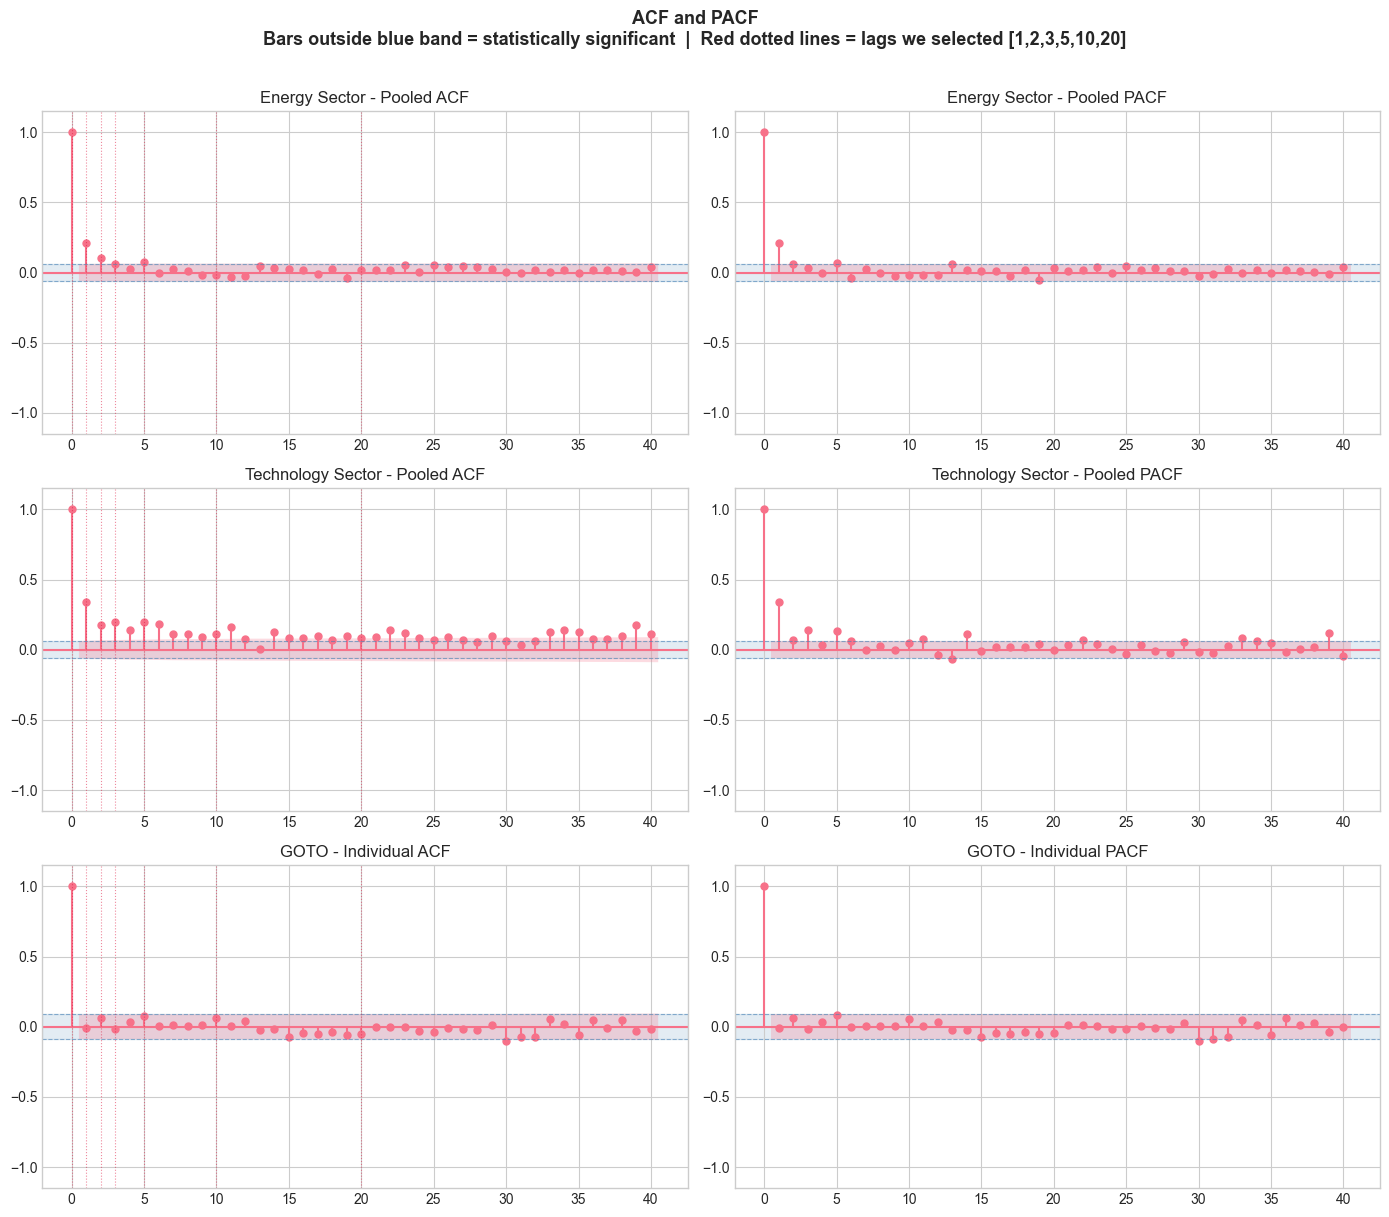


Energy pooled:
  Significant ACF lags (|r| > 0.05): [1, 2, 3, 5]
  Max |ACF|: 0.2082 at lag 1

Technology pooled:
  Significant ACF lags (|r| > 0.05): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20]
  Max |ACF|: 0.3368 at lag 1

GOTO individual:
  Significant ACF lags (|r| > 0.05): [2, 5, 10, 15, 17, 19, 20]
  Max |ACF|: 0.0776 at lag 5


In [33]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

# Confidence threshold for ~5%
def add_conf_band(ax, series, lags=40, alpha=0.05):
    n = len(series)
    # 1.96 approx for 95% CI
    z = 1.96
    bound = z / np.sqrt(n)
    ax.axhspan(-bound, bound, color='steelblue', alpha=0.15, zorder=0)
    ax.axhline(bound, color='steelblue', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.axhline(-bound, color='steelblue', linestyle='--', linewidth=0.8, alpha=0.6)

MAX_LAGS = 40 
sample_ticker = 'GOTO'

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Energy sector returns
energy_pooled = df[df['sector'] == 'Energy'].groupby('Date')['daily_return'].mean().dropna()
plot_acf(energy_pooled, lags=MAX_LAGS, ax=axes[0, 0], title='Energy Sector - Pooled ACF')
plot_pacf(energy_pooled, lags=MAX_LAGS, ax=axes[0, 1], title='Energy Sector - Pooled PACF', method='ywm')

# Technology sector returns
tech_pooled = df[df['sector'] == 'Technology'].groupby('Date')['daily_return'].mean().dropna()
plot_acf(tech_pooled, lags=MAX_LAGS, ax=axes[1, 0], title='Technology Sector - Pooled ACF')
plot_pacf(tech_pooled, lags=MAX_LAGS, ax=axes[1, 1], title='Technology Sector - Pooled PACF', method='ywm')

# Single representative ticker
ticker_returns = df[df['Ticker'] == sample_ticker]['daily_return'].dropna()
plot_acf(ticker_returns, lags=MAX_LAGS, ax=axes[2, 0], title=f'{sample_ticker} - Individual ACF')
plot_pacf(ticker_returns, lags=MAX_LAGS, ax=axes[2, 1], title=f'{sample_ticker} - Individual PACF', method='ywm')

add_conf_band(axes[0, 0], energy_pooled, lags=MAX_LAGS)
add_conf_band(axes[0, 1], energy_pooled, lags=MAX_LAGS)
add_conf_band(axes[1, 0], tech_pooled, lags=MAX_LAGS)
add_conf_band(axes[1, 1], tech_pooled, lags=MAX_LAGS)
add_conf_band(axes[2, 0], ticker_returns, lags=MAX_LAGS)
add_conf_band(axes[2, 1], ticker_returns, lags=MAX_LAGS)

for ax in axes.flat:
    ax.set_ylim(-1.15, 1.15)

# Chosen lag windows on each ACF plot
for ax in [axes[0, 0], axes[1, 0], axes[2, 0]]:
    for lag in [1, 2, 3, 5, 10, 20]:
        ax.axvline(x=lag, color='crimson', linestyle=':', linewidth=0.8, alpha=0.5)
    # legend entry for lag markers
    ax.axvline(x=0, color='crimson', linestyle=':', linewidth=0.8, alpha=0.5, label='Our lag windows')

plt.suptitle('ACF and PACF\n'
             'Bars outside blue band = statistically significant  |  '
             'Red dotted lines = lags we selected [1,2,3,5,10,20]',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

def summarize_acf(series, name, max_lag=20):
    acf_vals = [series.autocorr(lag=i) for i in range(1, max_lag + 1)]
    sig_lags = [i for i, v in enumerate(acf_vals, 1) if abs(v) > 0.05]
    print(f"\n{name}:")
    print(f"  Significant ACF lags (|r| > 0.05): {sig_lags if sig_lags else 'NONE : returns are near white noise'}")
    print(f"  Max |ACF|: {max(abs(v) for v in acf_vals):.4f} at lag {acf_vals.index(max(acf_vals, key=abs)) + 1}")

summarize_acf(energy_pooled, 'Energy pooled')
summarize_acf(tech_pooled, 'Technology pooled')
summarize_acf(ticker_returns, f'{sample_ticker} individual')

---
## Section 4: Rolling Window Statistics

Windows: [5, 10, 20, 50] trading days. All computed per-ticker with `groupby().rolling()`. These capture trend, volatility, volume regime, and momentum; statistical properties the LSTM can learn but which serve as strong baselines for classical models.

In [34]:
df


,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,sector,daily_return,...,close_open_gap_lag3,close_open_gap_lag5,close_open_gap_lag10,close_open_gap_lag20,price_position_lag1,price_position_lag2,price_position_lag3,price_position_lag5,price_position_lag10,price_position_lag20
0,2020-01-13,ABMM,1300.0,1515.0,1300.0,1515.0,1214.466431,500.0,Energy,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-16,ABMM,1495.0,1495.0,1490.0,1490.0,1194.425781,1500.0,Energy,-0.016502,...,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN
2,2020-01-20,ABMM,1490.0,1490.0,1490.0,1490.0,1194.425781,6000.0,Energy,0.000000,...,NaN,NaN,NaN,NaN,0.000000,1.000000,NaN,NaN,NaN,NaN
3,2020-01-23,ABMM,1475.0,1480.0,1470.0,1480.0,1186.409424,800.0,Energy,-0.006711,...,0.165385,NaN,NaN,NaN,0.500000,0.000000,1.000000,NaN,NaN,NaN
4,2020-01-28,ABMM,1450.0,1450.0,1450.0,1450.0,1162.360596,100.0,Energy,-0.020270,...,-0.003344,NaN,NaN,NaN,1.000000,0.500000,0.000000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95927,2024-05-13,ZYRX,149.0,149.0,144.0,146.0,146.000000,180100.0,Technology,-0.013514,...,-0.006803,-0.026667,-0.013423,-0.033333,1.000000,0.750000,0.857143,0.000000,0.500000,0.300000
95928,2024-05-14,ZYRX,146.0,146.0,142.0,146.0,146.000000,95800.0,Technology,0.000000,...,-0.006849,-0.013423,-0.020270,0.006944,0.400000,1.000000,0.750000,0.400000,0.000000,0.666667
95929,2024-05-15,ZYRX,143.0,146.0,135.0,140.0,140.000000,3749200.0,Technology,-0.041096,...,0.020690,-0.006803,0.013793,0.013605,1.000000,0.400000,1.000000,0.857143,0.400000,0.444444
95930,2024-05-16,ZYRX,141.0,141.0,138.0,139.0,139.000000,437800.0,Technology,-0.007143,...,-0.020134,-0.006849,-0.020000,0.000000,0.454545,1.000000,0.400000,0.750000,0.250000,1.000000


In [35]:
WINDOWS = [5, 10, 20, 50]

rolling_features = []

for ticker, group in df.groupby('Ticker'):
    idx = group.index
    group = group.sort_values('Date')

    for w in WINDOWS:
        roll = group.rolling(window=w, min_periods=max(w // 2, 2))

        # Trend - price relative to MA
        adj_close_ma = roll['Adj Close'].mean()
        df.loc[idx, f'price_vs_ma{w}'] = group['Adj Close'].values / adj_close_ma.values - 1
        # ^^ df.loc is pandas' label based indexer; selects rows and cols based by their labels not integer positions
        
        # realized vol over window
        ret_std = roll['daily_return'].std()
        df.loc[idx, f'volatility_{w}d'] = ret_std.values

        # current volume relative to rolling avg
        vol_ma = roll['Volume'].mean()
        df.loc[idx, f'volume_ratio_{w}d'] = group['Volume'].values / vol_ma.values
        vol_std = roll['Volume'].std()
        df.loc[idx, f'volume_std_{w}d'] = vol_std.values

        # rate of change over window
        roc = group['Adj Close'] / group['Adj Close'].shift(w) - 1
        df.loc[idx, f'momentum_{w}d'] = roc.values

        # distance from rolling high and low
        roll_high = roll['Close'].max()
        roll_low = roll['Close'].min()
        df.loc[idx, f'dist_from_high{w}'] = (group['Close'].values / roll_high.values - 1)
        df.loc[idx, f'dist_from_low{w}'] = (group['Close'].values / roll_low.values - 1)

    # autocorrelation over 20-day window (momentum/reversal signal)
    ret = group['daily_return']
    df.loc[idx, 'autocorr_20d'] = (
        ret.rolling(20, min_periods=10)
        .apply(lambda x: x.autocorr() if len(x) >= 5 else np.nan, raw=False)
        .values
    )

Autocorrelation: measures how correlated a time series is with a lagged version of itself. COmputed as 20 day rolling autocorrelation of daily return, use this as a reversal signal

In [36]:
# rolling feature names
rolling_features = (
    [f'price_vs_ma{w}' for w in WINDOWS]
    + [f'volatility_{w}d' for w in WINDOWS]
    + [f'volume_ratio_{w}d' for w in WINDOWS]
    + [f'volume_std_{w}d' for w in WINDOWS]
    + [f'momentum_{w}d' for w in WINDOWS]
    + [f'dist_from_high{w}' for w in WINDOWS]
    + [f'dist_from_low{w}' for w in WINDOWS]
    + ['autocorr_20d']
)

print(f"Rolling features created: {len(rolling_features)}")
print(f"  Windows: {WINDOWS}")
print(f"  Categories: price_vs_ma, volatility, volume_ratio, volume_std, "
      f"momentum, dist_from_high, dist_from_low, autocorr")

Rolling features created: 29
  Windows: [5, 10, 20, 50]
  Categories: price_vs_ma, volatility, volume_ratio, volume_std, momentum, dist_from_high, dist_from_low, autocorr


---
### Sanity Check: Price + Rolling MA Overlay (AI generated code)

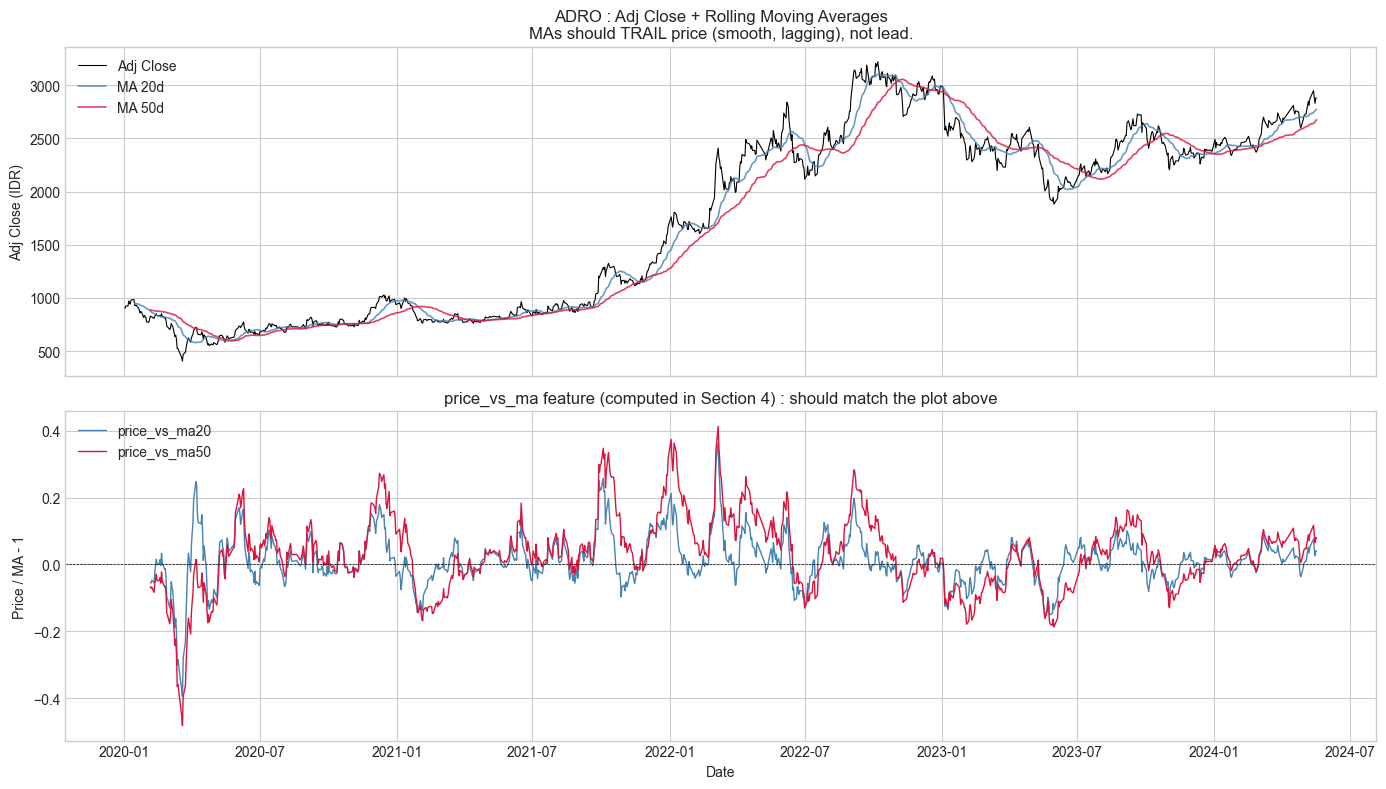

In [37]:
# Pick a ticker with enough history (no NaN in the rolling features)
sample_ticker = 'ADRO'
sample = df[df['Ticker'] == sample_ticker].copy()

# Compute rolling MAs directly for plotting (to verify our features match)
sample = sample.sort_values('Date')
sample['ma20'] = sample['Adj Close'].rolling(20, min_periods=10).mean()
sample['ma50'] = sample['Adj Close'].rolling(50, min_periods=25).mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: price + rolling MAs
ax1.plot(sample['Date'], sample['Adj Close'], color='black', linewidth=0.8, label='Adj Close')
ax1.plot(sample['Date'], sample['ma20'], color='steelblue', linewidth=1.2, alpha=0.8, label='MA 20d')
ax1.plot(sample['Date'], sample['ma50'], color='crimson', linewidth=1.2, alpha=0.8, label='MA 50d')
ax1.set_ylabel('Adj Close (IDR)')
ax1.set_title(f'{sample_ticker} : Adj Close + Rolling Moving Averages\nMAs should TRAIL price (smooth, lagging), not lead.')
ax1.legend(loc='upper left')

# Bottom: price_vs_ma feature (should match (Close/MA - 1) from the plot above)
sample_valid = sample.dropna(subset=['price_vs_ma20', 'price_vs_ma50'])
ax2.plot(sample_valid['Date'], sample_valid['price_vs_ma20'], color='steelblue', linewidth=1, label='price_vs_ma20')
ax2.plot(sample_valid['Date'], sample_valid['price_vs_ma50'], color='crimson', linewidth=1, label='price_vs_ma50')
ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax2.set_ylabel('Price / MA - 1')
ax2.set_xlabel('Date')
ax2.set_title('price_vs_ma feature (computed in Section 4) : should match the plot above')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [38]:
# feature values should be consistent with the plot
print(f"Latest valid row for {sample_ticker}:")
latest = sample_valid.iloc[-1]
print(f"  Date: {latest['Date'].date()}")
print(f"  Adj Close / MA20 - 1 (manual): {latest['Adj Close'] / latest['ma20'] - 1:.6f}")
print(f"  price_vs_ma20 (feature): {latest['price_vs_ma20']:.6f}")

Latest valid row for ADRO:
  Date: 2024-05-17
  Adj Close / MA20 - 1 (manual): 0.039148
  price_vs_ma20 (feature): 0.039148


---
### Lag Shift Verification

Scatter plot of `daily_return(t)` vs `daily_return_lag1(t+1)`. If `shift(1)` works correctly, `daily_return_lag1` at row `t+1` should equal `daily_return` at row `t`. On a scatter plot, all points should lie on the line y=x. If they don't, the shift direction is wrong.

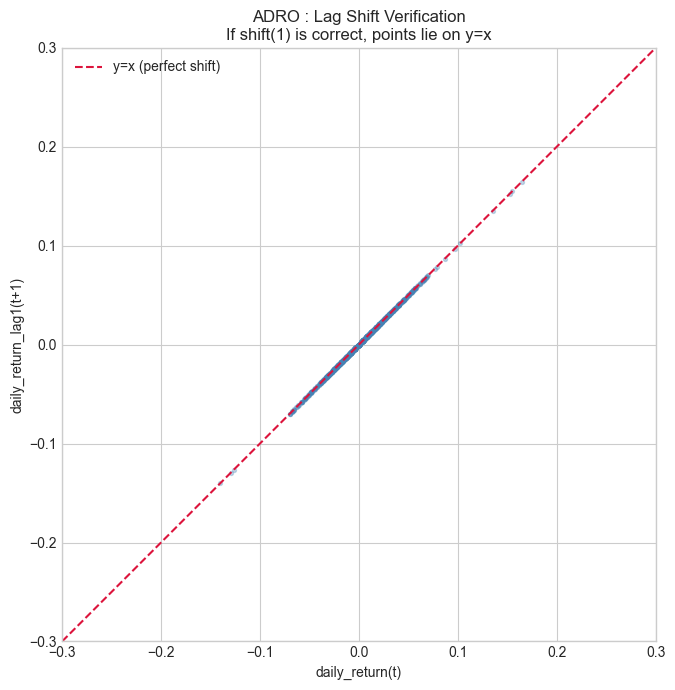

In [39]:
sub = df[df['Ticker'] == sample_ticker][['Date', 'daily_return', 'daily_return_lag1']].copy()

# If shift is correct: daily_return_lag1 at row t+1 = daily_return at row t
# So we plot: x = daily_return(t), y = daily_return_lag1(t+1) [i.e., shift y back by 1 to align]
sub['return_t'] = sub['daily_return']
sub['lag1_at_t_plus_1'] = sub['daily_return_lag1'].shift(-1)  # bring lag1(t+1) back to align with t

valid = sub.dropna(subset=['return_t', 'lag1_at_t_plus_1'])
# Sample 2000 points to avoid overplotting
sample_pts = valid.sample(min(2000, len(valid)), random_state=42)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(sample_pts['return_t'], sample_pts['lag1_at_t_plus_1'], alpha=0.3, s=8, color='steelblue')
ax.plot([-0.3, 0.3], [-0.3, 0.3], color='crimson', linestyle='--', linewidth=1.5, label='y=x (perfect shift)')
ax.set_xlabel('daily_return(t)')
ax.set_ylabel('daily_return_lag1(t+1)')
ax.set_title(f'{sample_ticker} : Lag Shift Verification\nIf shift(1) is correct, points lie on y=x')
ax.legend()
ax.set_xlim(-0.3, 0.3)
ax.set_ylim(-0.3, 0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

In [40]:
# Numerical check: correlation should be ~1.0
corr = valid['return_t'].corr(valid['lag1_at_t_plus_1'])
print(f"Correlation between daily_return(t) and daily_return_lag1(t+1): {corr:.6f}")
print(f"(Should be ~1.0 — confirms shift(1) correctly grabbed yesterday's return)")

# Show a few rows to manually verify
print(f"\nManual verification (first 5 rows of {sample_ticker}):")
check = sub[['Date', 'daily_return', 'daily_return_lag1']].head(6).copy()
check['lag1_should_equal_prev_return'] = check['daily_return'].shift(1)
print(check.to_string(index=False))
print("Column 'daily_return_lag1' should equal 'lag1_should_equal_prev_return'")

Correlation between daily_return(t) and daily_return_lag1(t+1): 1.000000
(Should be ~1.0 — confirms shift(1) correctly grabbed yesterday's return)

Manual verification (first 5 rows of ADRO):
      Date  daily_return  daily_return_lag1  lag1_should_equal_prev_return
2020-01-02           NaN                NaN                            NaN
2020-01-03      0.024820                NaN                            NaN
2020-01-06      0.000000           0.024820                       0.024820
2020-01-07      0.051194           0.000000                       0.000000
2020-01-08     -0.022727           0.051194                       0.051194
2020-01-09     -0.006645          -0.022727                      -0.022727
Column 'daily_return_lag1' should equal 'lag1_should_equal_prev_return'


In [41]:
df

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,sector,daily_return,...,dist_from_high20,dist_from_low20,price_vs_ma50,volatility_50d,volume_ratio_50d,volume_std_50d,momentum_50d,dist_from_high50,dist_from_low50,autocorr_20d
0,2020-01-13,ABMM,1300.0,1515.0,1300.0,1515.0,1214.466431,500.0,Energy,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-16,ABMM,1495.0,1495.0,1490.0,1490.0,1194.425781,1500.0,Energy,-0.016502,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-20,ABMM,1490.0,1490.0,1490.0,1490.0,1194.425781,6000.0,Energy,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-23,ABMM,1475.0,1480.0,1470.0,1480.0,1186.409424,800.0,Energy,-0.006711,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-28,ABMM,1450.0,1450.0,1450.0,1450.0,1162.360596,100.0,Energy,-0.020270,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95927,2024-05-13,ZYRX,149.0,149.0,144.0,146.0,146.000000,180100.0,Technology,-0.013514,...,-0.020134,0.013889,-0.053546,0.016606,0.681928,463044.590333,-0.098765,-0.109756,0.013889,-0.273934
95928,2024-05-14,ZYRX,146.0,146.0,142.0,146.0,146.000000,95800.0,Technology,0.000000,...,-0.020134,0.013889,-0.052071,0.016279,0.370580,463361.797642,-0.075949,-0.109756,0.013889,-0.299601
95929,2024-05-15,ZYRX,143.0,146.0,135.0,140.0,140.000000,3749200.0,Technology,-0.041096,...,-0.060403,0.000000,-0.088660,0.017084,11.334079,676561.599606,-0.125000,-0.146341,0.000000,-0.292394
95930,2024-05-16,ZYRX,141.0,141.0,138.0,139.0,139.000000,437800.0,Technology,-0.007143,...,-0.060811,0.000000,-0.092571,0.017049,1.303783,676406.617487,-0.136646,-0.152439,0.000000,-0.183682


---
## Section 5: Cross-Sectional & Sector Features

Instead of Technical Analysis Indicators (TA) which are just functions of the underlying price action, cross-sectional and sector features encodes new information about how a stock behaves relative to its sector peers. Unlike TA indicators, this cannot be derived from a single ticker's OHLCV history.

In [42]:
cross_features = []

# sector avg return / date (EXCLUDE SELF!!!!!!)
def sector_avg_excluding(group):
    """each ticker, compute sector mean return"""
    n = len(group)
    total = group.sum()
    # (total - self) / (n - 1); handle n==1 edge case
    return pd.Series(
        np.where(n > 1, (total - group.values) / (n - 1), np.nan),
        index=group.index
    )

In [43]:
df = df.sort_values(['Date', 'sector', 'Ticker']).reset_index(drop=True)

In [44]:
# group by Date + Sector
gs = df.groupby(['Date', 'sector'])

In [45]:
# sector average return 
df['sector_avg_return'] = gs['daily_return'].transform(sector_avg_excluding)

In [46]:
# sector return dispersion (std of returns across sector peers on same day)
df['sector_return_dispersion'] = gs['daily_return'].transform('std')

In [47]:
# relative strength: this stock vs its sector
df['relative_strength'] = df['daily_return'] - df['sector_avg_return']

In [48]:
# market breadth: fraction of sector peers with positive return
df['sector_pos_frac'] = gs['daily_return'].transform(
    lambda x: (x > 0).mean()
)

In [49]:
# sector volume trend: total sector volume today
df['sector_total_volume'] = gs['Volume'].transform('sum')

In [50]:
cross_features.extend([
    'sector_avg_return', 'sector_return_dispersion', 'relative_strength',
    'sector_pos_frac', 'sector_total_volume'
])

In [51]:
# rolling relative strength
for w in [5, 20]:
    col = f'rel_strength_ma{w}'
    df[col] = df.groupby('Ticker')['relative_strength'].transform(
        lambda x: x.rolling(w, min_periods=max(w // 2, 2)).mean()
    )
    cross_features.append(col)

In [52]:
# sector volume relative to its own 20-day rolling avg (per-sector)
for sector_name in df['sector'].unique():
    mask = df['sector'] == sector_name
    daily_vol = df.loc[mask, ['Date', 'sector_total_volume']].drop_duplicates()
    daily_vol = daily_vol.sort_values('Date')
    daily_vol['sector_vol_ma20'] = daily_vol['sector_total_volume'].rolling(20, min_periods=10).mean()
    daily_vol['sector_vol_ratio'] = daily_vol['sector_total_volume'] / daily_vol['sector_vol_ma20']
    mapper = daily_vol.set_index('Date')['sector_vol_ratio'].to_dict()
    df.loc[mask, 'sector_vol_regime'] = df.loc[mask, 'Date'].map(mapper)

In [53]:
cross_features.append('sector_vol_regime')

In [54]:
print(f"Cross-sectional features created: {len(cross_features)}")
print(f"  Features: {cross_features}")
print(f"\nSample sector stats (latest 5 days, Energy sector):")
energy_sample = df[df['sector'] == 'Energy'].drop_duplicates(['Date']).tail(5)
display_cols = ['Date'] + [c for c in cross_features if c in df.columns]
print(energy_sample[display_cols].to_string(index=False))

Cross-sectional features created: 8
  Features: ['sector_avg_return', 'sector_return_dispersion', 'relative_strength', 'sector_pos_frac', 'sector_total_volume', 'rel_strength_ma5', 'rel_strength_ma20', 'sector_vol_regime']

Sample sector stats (latest 5 days, Energy sector):
      Date  sector_avg_return  sector_return_dispersion  relative_strength  sector_pos_frac  sector_total_volume  rel_strength_ma5  rel_strength_ma20  sector_vol_regime
2024-05-13          -0.000928                  0.043260           0.024427         0.316456         2076404700.0          0.005412          -0.003312           0.788292
2024-05-14           0.001998                  0.030023          -0.007100         0.371795         3060414600.0          0.003280          -0.003376           1.131837
2024-05-15           0.006043                  0.045599          -0.057325         0.379747         3333266900.0         -0.009986          -0.005477           1.184458
2024-05-16           0.004661                  0

---
### Cross-Sectional Stock vs Sector Returns

For one date and one sector, visualize `relative_strength` = stock return − sector average return (ex-self).

Wide distribution = high cross-sectional dispersion that day (stocks moved independently); narrow distribution = macro/sector-driven day.

In [55]:
sample_date = pd.Timestamp('2024-05-15')
sector = 'Technology'
N_SAMPLE = 12

In [56]:
mask = (df['Date'] == sample_date) & (df['sector'] == sector)
day_slice = df[mask][['Ticker', 'daily_return', 'sector_avg_return', 'relative_strength']].dropna()
day_slice = day_slice.sort_values('relative_strength')

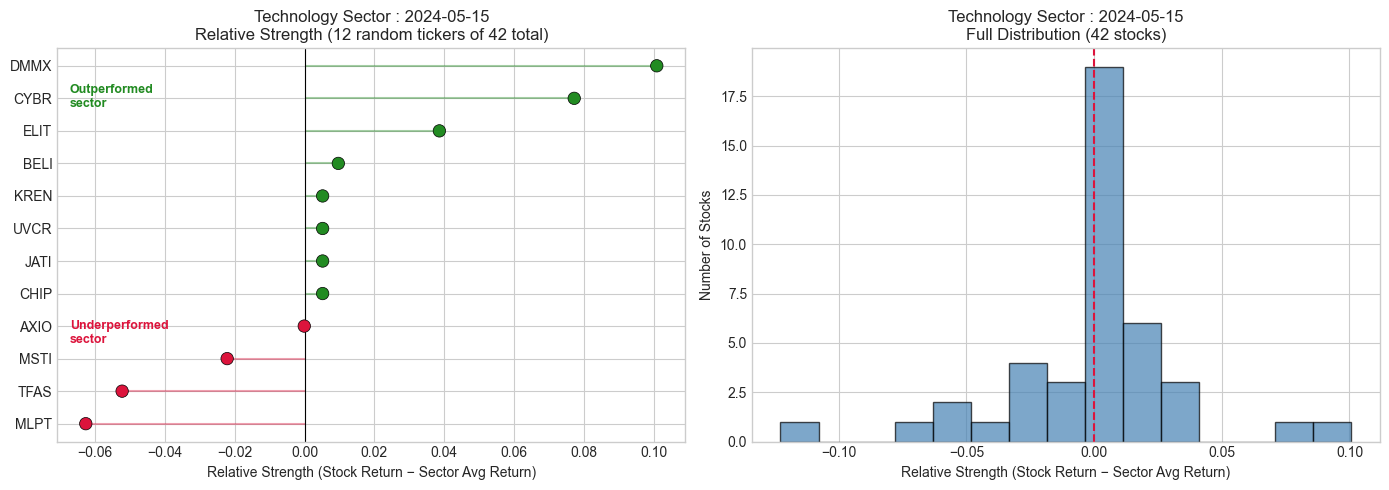

Technology sector on 2024-05-15 (42 stocks):
  Relative strength mean: -0.000000 (should be ~0 by construction)
  Relative strength std:  0.035954
  Range: [-0.1229, 0.1008]
  Outperformed sector: 27/42
  Underperformed:      15/42


In [57]:
# === LEFT 
rng = np.random.default_rng(42)
sample_tickers = rng.choice(day_slice['Ticker'].unique(), size=min(N_SAMPLE, len(day_slice)), replace=False)
sample_slice = day_slice[day_slice['Ticker'].isin(sample_tickers)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# dot = one stock's deviation from sector average
y_positions = range(len(sample_slice))
colors = ['forestgreen' if v > 0 else 'crimson' for v in sample_slice['relative_strength']]
ax1.hlines(y=y_positions, xmin=0, xmax=sample_slice['relative_strength'], 
           colors=colors, alpha=0.4, linewidth=1.5)
ax1.scatter(sample_slice['relative_strength'], y_positions, 
            c=colors, s=80, edgecolors='black', linewidth=0.5, zorder=3)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax1.set_yticks(y_positions)
ax1.set_yticklabels(sample_slice['Ticker'])
ax1.set_xlabel('Relative Strength (Stock Return − Sector Avg Return)')
ax1.set_title(f'{sector} Sector : {sample_date.date()}\nRelative Strength ({len(sample_slice)} random tickers of {len(day_slice)} total)')
ax1.annotate('Outperformed\nsector', xy=(0.02, 0.85), xycoords='axes fraction',
            fontsize=9, color='forestgreen', ha='left', fontweight='bold')
ax1.annotate('Underperformed\nsector', xy=(0.02, 0.25), xycoords='axes fraction', 
            fontsize=9, color='crimson', ha='left', fontweight='bold')

# === RIGHT
# histogram of ALL stocks in the sector
ax2.hist(day_slice['relative_strength'].dropna(), bins=15, color='steelblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='crimson', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Relative Strength (Stock Return − Sector Avg Return)')
ax2.set_ylabel('Number of Stocks')
ax2.set_title(f'{sector} Sector : {sample_date.date()}\nFull Distribution ({len(day_slice)} stocks)')

plt.tight_layout()
plt.show()

print(f"{sector} sector on {sample_date.date()} ({len(day_slice)} stocks):")
print(f"  Relative strength mean: {day_slice['relative_strength'].mean():.6f} (should be ~0 by construction)")
print(f"  Relative strength std:  {day_slice['relative_strength'].std():.6f}")
print(f"  Range: [{day_slice['relative_strength'].min():.4f}, {day_slice['relative_strength'].max():.4f}]")
print(f"  Outperformed sector: {(day_slice['relative_strength'] > 0).sum()}/{len(day_slice)}")
print(f"  Underperformed:      {(day_slice['relative_strength'] < 0).sum()}/{len(day_slice)}")

---
## Section 6: Calendar Features

In [58]:
df['day_of_week'] = df['Date'].dt.dayofweek  # 0=Monday, 4=Friday
df['month'] = df['Date'].dt.month
df['quarter'] = df['Date'].dt.quarter

calendar_features = ['day_of_week', 'month', 'quarter']

print("Calendar features added:", calendar_features)
print(f"\nDay-of-week distribution:")
print(df['day_of_week'].value_counts().sort_index())

Calendar features added: ['day_of_week', 'month', 'quarter']

Day-of-week distribution:
day_of_week
0    19333
1    19839
2    19167
3    18833
4    18760
Name: count, dtype: int64


---
## Section 7: Target Variable

`target = 1` if Close(t+1) > Close(t), else `0`. Computed per-ticker with `shift(-1)`. The last row of each ticker gets `NaN` target (no next day to observe) — this is expected and will be dropped in Section 8.

In [59]:
# compute target per ticker: 1 if Close(t+1) > Close(t), else 0
# Use np.where to explicitly set NaN where shift(-1) produces NaN (last row per ticker)
next_close = df.groupby('Ticker')['Close'].shift(-1)
df['target'] = np.where(
    next_close.isnull(),
    np.nan,
    (next_close > df['Close']).astype(int)
)

target_counts = df['target'].value_counts(normalize=True)
nan_targets = df['target'].isnull().sum()
print("Target distribution (excluding NaN):")
print(f"  Down/Flat (0): {target_counts.get(0, 0):.4f} ({target_counts.get(0, 0)*100:.1f}%)")
print(f"  Up (1):        {target_counts.get(1, 0):.4f} ({target_counts.get(1, 0)*100:.1f}%)")
print(f"  NaN:           {nan_targets:,} rows (expected: {df['Ticker'].nunique()} = one per ticker)")

sample_ticker = df['Ticker'].iloc[0]
sample = df[df['Ticker'] == sample_ticker].head(10).copy()
print(f"\nLeakage sanity check — {sample_ticker} (first 10 rows):")
print(sample[['Date', 'Close', 'target']].to_string(index=False))
print("  target=1 means Close(t+1) > Close(t) — verify manually above")
print("  Last row should have target=NaN")

Target distribution (excluding NaN):
  Down/Flat (0): 0.6482 (64.8%)
  Up (1):        0.3518 (35.2%)
  NaN:           130 rows (expected: 130 = one per ticker)

Leakage sanity check — ADRO (first 10 rows):
      Date  Close  target
2020-01-02 1495.0     0.0
2020-01-03 1465.0     0.0
2020-01-06 1465.0     1.0
2020-01-07 1540.0     0.0
2020-01-08 1505.0     0.0
2020-01-09 1495.0     1.0
2020-01-10 1550.0     1.0
2020-01-13 1565.0     0.0
2020-01-14 1560.0     0.0
2020-01-15 1475.0     0.0
  target=1 means Close(t+1) > Close(t) — verify manually above
  Last row should have target=NaN


---
### Verify labeling

In [60]:
next_close = df.groupby('Ticker')['Close'].shift(-1)
expected_target = (next_close > df['Close']).astype(int)

mask = df['target'].notna()
actual = df.loc[mask, 'target'].astype(int)
expected = expected_target[mask]

mismatches = actual != expected
n_total = len(actual)
n_mismatch = mismatches.sum()

print(f"Total rows verified: {n_total:,}")
print(f"Mismatches found:{n_mismatch:,} ({n_mismatch / n_total * 100:.4f}%)")

if n_mismatch > 0:
    print(f"\nSample mismatches:")
    mismatch_idx = mismatches[mismatches].index[:10]
    mismatch_df = df.loc[mismatch_idx, ['Date', 'Ticker', 'Close', 'target']].copy()
    mismatch_df['Close(t+1)'] = next_close[mismatch_idx]
    mismatch_df['expected'] = expected[mismatch_idx]
    print(mismatch_df.to_string(index=True))
else:
    print("\nLabel correct")

Total rows verified: 95,802
Mismatches found:0 (0.0000%)

Label correct


In [61]:
# Replace inf/-inf from pct_change division-by-zero with NaN
# (occurs when prior-day Volume was 0; these will be dropped in Section 8)
inf_mask = np.isinf(df.select_dtypes(include=[np.number]))
inf_cols = inf_mask.any()
if inf_cols.any():
    inf_summary = inf_mask.sum()
    inf_summary = inf_summary[inf_summary > 0]
    print(f"Replacing inf values with NaN in {len(inf_summary)} columns:")
    for col, count in inf_summary.items():
        tickers = df.loc[inf_mask[col], 'Ticker'].unique()
        print(f"  {col}: {count} rows — tickers: {list(tickers)}")
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    print(f"\nTotal inf values replaced: {inf_mask.sum().sum()}")
else:
    print("No inf values found.")

Replacing inf values with NaN in 8 columns:
  close_open_gap: 3 rows — tickers: ['COAL', 'CASH', 'EDGE']
  volume_change: 3 rows — tickers: ['AKRA', 'ITMG', 'RIGS']
  volume_change_lag1: 3 rows — tickers: ['AKRA', 'ITMG', 'RIGS']
  volume_change_lag2: 3 rows — tickers: ['AKRA', 'ITMG', 'RIGS']
  volume_change_lag3: 3 rows — tickers: ['AKRA', 'ITMG', 'RIGS']
  volume_change_lag5: 3 rows — tickers: ['AKRA', 'ITMG', 'RIGS']
  volume_change_lag10: 3 rows — tickers: ['AKRA', 'ITMG', 'RIGS']
  volume_change_lag20: 3 rows — tickers: ['AKRA', 'ITMG', 'RIGS']



Total inf values replaced: 24


---
## Section 8: Drop NaN Rows

NaN sources: initial rolling windows (first ~50 days per ticker), shift operations (first row per ticker), and the final target row per ticker. We drop all rows with any NaN feature to keep the dataset clean.

In [62]:
before = len(df)
feature_cols = base_cols + lagged_features + rolling_features + cross_features + calendar_features
all_model_cols = feature_cols + ['target']

# consider columns that actually exist
all_model_cols = [c for c in all_model_cols if c in df.columns]

df_clean = df.dropna(subset=all_model_cols).copy()
after = len(df_clean)

print(f"Rows before NaN drop:  {before:>8,}")
print(f"Rows after NaN drop:   {after:>8,}")
print(f"Rows dropped:           {before - after:>8,} ({(before - after) / before * 100:.1f}%)")

# ticker: how many rows remain?
ticker_survival = df_clean.groupby('Ticker').size()
print(f"\nTicker row counts after NaN drop:")
print(f"  Min:    {ticker_survival.min():,}")
print(f"  Median: {ticker_survival.median():.0f}")
print(f" Max:    {ticker_survival.max():,}")

low_history = ticker_survival[ticker_survival < 252]
if len(low_history) > 0:
    print(f"\nckers with <252 rows (~1 year): {len(low_history)}")
    for t, n in low_history.items():
        print(f"    {t}: {n} rows")
else:
    print(f"\nAll tickers have >=252 rows — no tickers need removal.")

# veify no NaN remains
remaining_nan = df_clean[all_model_cols].isnull().sum().sum()
print(f"\nRemaining NaN values: {remaining_nan}")

Rows before NaN drop:    95,932
Rows after NaN drop:     84,051
Rows dropped:             11,881 (12.4%)

Ticker row counts after NaN drop:
  Min:    4
  Median: 792
 Max:    1,007

ckers with <252 rows (~1 year): 23
    ALII: 5 rows
    ARTI: 107 rows
    AWAN: 197 rows
    CBRE: 89 rows
    CGAS: 19 rows
    CHIP: 236 rows
    CNKO: 28 rows
    CUAN: 198 rows
    CYBR: 130 rows
    ENVY: 133 rows
    HILL: 228 rows
    HUMI: 128 rows
    IOTF: 89 rows
    IRSX: 158 rows
    JATI: 121 rows
    MAHA: 140 rows
    MENN: 197 rows
    MKAP: 4 rows
    MSTI: 66 rows
    RGAS: 66 rows
    RMKO: 136 rows
    TOSK: 5 rows
    TRON: 223 rows



Remaining NaN values: 0


---
## Section 9: Export Full Feature Engineered Dataset (Pre-Split, Per Sector)

- `Dataset/processed/energy.parquet` 
- `Dataset/processed/technology.parquet` 

Columns: Date, Ticker, Open, High, Low, Close, Adj Close, Volume, sector, all engineered features, target.

In [63]:
feature_cols_final = [c for c in feature_cols if c in df_clean.columns]
export_cols = ['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'] + feature_cols_final + ['target']

total_rows = 0
sector_sizes = {}

for sector in sorted(df_clean['sector'].unique()):
    mask = df_clean['sector'] == sector
    sector_df = df_clean[mask][export_cols].copy()
    sector_name = sector.lower()
    path = os.path.join(OUTPUT_DIR, f'{sector_name}.parquet')

    sector_df.to_parquet(path, index=False, compression='snappy')

    size_mb = os.path.getsize(path) / (1024**2)
    n_tickers = sector_df['Ticker'].nunique()
    sector_sizes[sector] = {'rows': len(sector_df), 'tickers': n_tickers, 'size_mb': size_mb}
    total_rows += len(sector_df)

    tc = sector_df['target'].value_counts()
    print(f"  {sector:<12} {n_tickers:>3} tickers  {len(sector_df):>8,} rows  {size_mb:>6.1f} MB  "
          f"target 0={tc.get(0,0):,} 1={tc.get(1,0):,}")

print(f"\nTotal: {total_rows:,} rows across {len(sector_sizes)} sectors → {OUTPUT_DIR}/")

feature_final_list = [c for c in feature_cols_final if c in df_clean.columns]
col_ref = pd.DataFrame({
    'column': (['Date', 'Ticker', 'sector', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
               + feature_final_list + ['target']),
    'group': (['metadata'] * 3 + ['ohlcv'] * 6 + ['feature'] * len(feature_final_list) + ['target'])
})
col_ref.to_csv(os.path.join(OUTPUT_DIR, 'feature_reference.csv'), index=False)
print(f"feat reference saved: {os.path.join(OUTPUT_DIR, 'feature_reference.csv')} ({len(feature_final_list)} features)")

  Energy        82 tickers    58,418 rows    24.4 MB  target 0=36,013 1=22,405


  Technology    44 tickers    25,633 rows    10.7 MB  target 0=16,527 1=9,106

Total: 84,051 rows across 2 sectors → Dataset\processed/
feat reference saved: Dataset\processed\feature_reference.csv (77 features)


---
# Part 3: Compliant Ticker Reduction, Feature Capping, Model Training, and Evaluation

Source notebook: `03_model_training_evaluation.ipynb`. Enforces the Topic C modeling cap with 56 Energy + 44 Technology = 100 tickers, selects the top 40 features using training data only, applies temporal train/validation/test splits, trains the Logistic Regression baseline and final Random Forest model, and exports evaluation artifacts.

# IDX Next-Day Price Direction Prediction
## Model Training & Evaluation

This notebook is intentionally separate from the EDA and feature-engineering notebooks. It loads the already exported feature dataset from `Dataset/processed`, reconstructs the next trading date from `Dataset/cleaned`, applies a strictly temporal split, trains classifiers, and evaluates them with metrics suitable for an imbalanced binary classification task.

Prediction timing assumption: features observed on day `t` are used after market close on day `t` to predict whether `Close(t+1) > Close(t)`. Logistic Regression is retained as an interpretable baseline; Random Forest is the selected final model because it performs better on the validation/test ranking and correlation metrics.

---
## Section 1: Setup

In [64]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    matthews_corrcoef,
    precision_score,
    PrecisionRecallDisplay,
    recall_score,
    RocCurveDisplay,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path('Dataset')
PROCESSED_DIR = DATA_DIR / 'processed'
CLEANED_DIR = DATA_DIR / 'cleaned'
MODEL_OUTPUT_DIR = DATA_DIR / 'model_outputs'
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Processed dir: {PROCESSED_DIR.resolve()}')
print(f'Cleaned dir:   {CLEANED_DIR.resolve()}')
print(f'Output dir:    {MODEL_OUTPUT_DIR.resolve()}')

Processed dir: C:\Users\Rafi\OneDrive\Documents\CSUI24\Sem 4\Kasdad\miniproject\JCI-Time-Series\Dataset\processed
Cleaned dir:   C:\Users\Rafi\OneDrive\Documents\CSUI24\Sem 4\Kasdad\miniproject\JCI-Time-Series\Dataset\cleaned
Output dir:    C:\Users\Rafi\OneDrive\Documents\CSUI24\Sem 4\Kasdad\miniproject\JCI-Time-Series\Dataset\model_outputs


---
## Section 2: Load Processed Modeling Dataset

The processed parquet files contain engineered features and the binary target. If the files do not include a `sector` column, the sector is restored from the filename.

In [65]:
SECTOR_FILES = {
    'Energy': PROCESSED_DIR / 'energy.parquet',
    'Technology': PROCESSED_DIR / 'technology.parquet',
}

frames = []
for sector, path in SECTOR_FILES.items():
    if not path.exists():
        raise FileNotFoundError(f'Missing processed file: {path}')
    part = pd.read_parquet(path)
    if 'sector' not in part.columns:
        part['sector'] = sector
    frames.append(part)

model_df = pd.concat(frames, ignore_index=True)
model_df['Date'] = pd.to_datetime(model_df['Date'])
model_df['target'] = model_df['target'].astype(int)
model_df = model_df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

print(f'Rows:          {len(model_df):,}')
print(f'Tickers:       {model_df["Ticker"].nunique():,}')
print(f'Date range:    {model_df["Date"].min().date()} to {model_df["Date"].max().date()}')
print('Sector rows:')
print(model_df['sector'].value_counts())
print('Target balance:')
print(model_df['target'].value_counts(normalize=True).sort_index().rename({0: 'Down/Flat', 1: 'Up'}))

Rows:          84,051
Tickers:       126
Date range:    2020-03-12 to 2024-05-16
Sector rows:
sector
Energy        58418
Technology    25633
Name: count, dtype: int64
Target balance:
target
Down/Flat    0.625097
Up           0.374903
Name: proportion, dtype: float64


---
## Section 2B: Ticker Universe Reduction

Topic C limits the modeling universe to at most 100 stocks across 2-3 IDX-IC sectors. To make this notebook compliant and reproducible while using the full cap, the model keeps 56 Energy tickers and 44 Technology tickers. Tickers are ranked within each sector by processed row count, then median volume, then average volume.

The processed dataset currently contains 44 Technology tickers after cleaning and feature-engineering filters, so all available Technology tickers are retained. Energy is capped at 56 tickers so the final modeling universe is 56 Energy + 44 Technology = 100 tickers.

In [66]:
TICKER_TARGETS = {
    'Energy': 56,
    'Technology': 44,
}

selection_rows = []
selected_tickers = []

for sector, target_n in TICKER_TARGETS.items():
    sector_df = model_df[model_df['sector'] == sector].copy()
    if sector_df.empty:
        raise ValueError(f'No rows found for sector: {sector}')

    ticker_rank = (
        sector_df.groupby('Ticker')
        .agg(
            rows=('Date', 'size'),
            start_date=('Date', 'min'),
            end_date=('Date', 'max'),
            median_volume=('Volume', 'median'),
            avg_volume=('Volume', 'mean'),
            up_rate=('target', 'mean'),
        )
        .reset_index()
        .sort_values(
            ['rows', 'median_volume', 'avg_volume', 'Ticker'],
            ascending=[False, False, False, True],
        )
    )

    available_n = len(ticker_rank)
    selected_n = min(target_n, available_n)
    selected = ticker_rank.head(selected_n).copy()
    selected['sector'] = sector
    selected['target_n'] = target_n
    selected['available_n'] = available_n
    selected['selected_n'] = selected_n

    selection_rows.append(selected)
    selected_tickers.extend(selected['Ticker'].tolist())

    if available_n < target_n:
        print(
            f'{sector}: requested {target_n} tickers, but only {available_n} are available '
            'after cleaning/feature engineering; keeping all available tickers.'
        )
    else:
        print(f'{sector}: selected top {selected_n} of {available_n} available tickers.')

ticker_selection = pd.concat(selection_rows, ignore_index=True)
model_df = model_df[model_df['Ticker'].isin(selected_tickers)].copy()
model_df = model_df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

selection_summary = (
    ticker_selection.groupby('sector')
    .agg(
        available_tickers=('available_n', 'first'),
        selected_tickers=('Ticker', 'nunique'),
        target_tickers=('target_n', 'first'),
        selected_rows=('rows', 'sum'),
    )
    .reindex(TICKER_TARGETS.keys())
)

print('Ticker selection summary:')
display(selection_summary)

print(f'Final modeling universe: {model_df["Ticker"].nunique()} tickers, {len(model_df):,} rows')
print('Final sector ticker counts:')
print(model_df.groupby('sector')['Ticker'].nunique())

if model_df['Ticker'].nunique() > 100:
    raise ValueError('Ticker cap violated: selected more than 100 tickers')

print('Top selected tickers by sector:')
display(ticker_selection[['sector', 'Ticker', 'rows', 'median_volume', 'avg_volume', 'up_rate']].head(20))

Energy: selected top 56 of 82 available tickers.


Technology: selected top 44 of 44 available tickers.


Ticker selection summary:


,available_tickers,selected_tickers,target_tickers,selected_rows
sector,,,,
Energy,82,56,56,51086
Technology,44,44,44,25633


Final modeling universe: 100 tickers, 76,719 rows
Final sector ticker counts:
sector
Energy        56
Technology    44
Name: Ticker, dtype: int64
Top selected tickers by sector:


,sector,Ticker,rows,median_volume,avg_volume,up_rate
0,Energy,PGAS,1007,73593700.0,1.093538e+08,0.442900
1,Energy,ELSA,1007,36650400.0,6.833086e+07,0.424032
2,Energy,HRUM,1007,20970800.0,3.805830e+07,0.456802
3,Energy,INDY,1007,13986900.0,2.364508e+07,0.446872
4,Energy,SOCI,1007,8155200.0,1.796817e+07,0.367428
5,Energy,PSSI,1007,968100.0,2.034849e+06,0.397219
6,Energy,MBSS,1007,609100.0,1.607242e+06,0.398213
7,Energy,ADRO,1006,73200950.0,9.217022e+07,0.462227
8,Energy,MEDC,1006,72713550.0,9.372277e+07,0.439364
9,Energy,DOID,1006,37771350.0,7.953848e+07,0.441352


---
## Section 3: Feature Column Selection

Only engineered feature columns are used as model inputs. Metadata, raw OHLCV columns, the target, and split-related columns are excluded from `X`.

In [67]:
FEATURE_REFERENCE_PATH = PROCESSED_DIR / 'feature_reference.csv'

if FEATURE_REFERENCE_PATH.exists():
    feature_ref = pd.read_csv(FEATURE_REFERENCE_PATH)
    if {'column', 'group'}.issubset(feature_ref.columns):
        feature_cols = feature_ref.loc[feature_ref['group'].eq('feature'), 'column'].tolist()
    else:
        feature_cols = []
else:
    feature_ref = pd.DataFrame()
    feature_cols = []

if not feature_cols:
    excluded = {
        'Date', 'target_date', 'split', 'Ticker', 'sector', 'target',
        'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
    }
    feature_cols = [c for c in model_df.columns if c not in excluded]

missing_features = [c for c in feature_cols if c not in model_df.columns]
if missing_features:
    raise ValueError(f'Feature columns missing from model_df: {missing_features[:10]}')

forbidden_inputs = {
    'Date', 'target_date', 'split', 'Ticker', 'sector', 'target',
    'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
}
leaky_inputs = sorted(set(feature_cols) & forbidden_inputs)
if leaky_inputs:
    raise ValueError(f'Forbidden columns included in feature set: {leaky_inputs}')

print(f'Feature count: {len(feature_cols)}')
print(feature_cols[:15])

Feature count: 77
['daily_return', 'log_return', 'high_low_spread', 'close_open_gap', 'price_position', 'volume_change', 'log_volume', 'daily_return_lag1', 'daily_return_lag2', 'daily_return_lag3', 'daily_return_lag5', 'daily_return_lag10', 'daily_return_lag20', 'volume_change_lag1', 'volume_change_lag2']


---
## Section 4: Reconstruct Target Date And Verify Label

The split is based on the date being predicted, not merely the feature row date. The current processed dataset may not contain `target_date`, so this notebook reconstructs it from the cleaned OHLCV files.

In [68]:
cleaned_frames = []
for sector, path in {
    'Energy': CLEANED_DIR / 'energy.parquet',
    'Technology': CLEANED_DIR / 'technology.parquet',
}.items():
    if not path.exists():
        raise FileNotFoundError(f'Missing cleaned file: {path}')
    part = pd.read_parquet(path)
    part['sector'] = sector
    cleaned_frames.append(part[['Date', 'Ticker', 'Close', 'sector']])

cleaned_df = pd.concat(cleaned_frames, ignore_index=True)
cleaned_df['Date'] = pd.to_datetime(cleaned_df['Date'])
cleaned_df = cleaned_df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

g = cleaned_df.groupby('Ticker')
cleaned_df['target_date'] = g['Date'].shift(-1)
cleaned_df['next_close'] = g['Close'].shift(-1)
cleaned_df['expected_target'] = np.where(
    cleaned_df['next_close'].isna(),
    np.nan,
    (cleaned_df['next_close'] > cleaned_df['Close']).astype(int),
)

target_lookup = cleaned_df[['Ticker', 'Date', 'target_date', 'expected_target']]
model_df = model_df.drop(columns=[c for c in ['target_date'] if c in model_df.columns])
model_df = model_df.merge(target_lookup, on=['Ticker', 'Date'], how='left')

missing_target_date = model_df['target_date'].isna().sum()
if missing_target_date:
    raise ValueError(f'{missing_target_date:,} model rows are missing target_date')

label_mismatch = (model_df['target'].astype(float) != model_df['expected_target']).sum()
print(f'Missing target_date rows: {missing_target_date:,}')
print(f'Label mismatches vs cleaned OHLCV: {label_mismatch:,}')
if label_mismatch:
    display(model_df.loc[model_df['target'].astype(float) != model_df['expected_target'],
                         ['Date', 'Ticker', 'Close', 'target', 'expected_target']].head())
    raise ValueError('Target labels do not match cleaned OHLCV reconstruction')

model_df = model_df.drop(columns=['expected_target'])

Missing target_date rows: 0
Label mismatches vs cleaned OHLCV: 0


---
## Section 5: Temporal Train/Validation/Test Split

The split uses `target_date` so no training row uses a label from the validation or test period.

In [69]:
TRAIN_END = pd.Timestamp('2023-01-02')
VALID_END = pd.Timestamp('2024-01-02')

model_df['split'] = np.select(
    [
        model_df['target_date'] < TRAIN_END,
        (model_df['target_date'] >= TRAIN_END) & (model_df['target_date'] < VALID_END),
        model_df['target_date'] >= VALID_END,
    ],
    ['train', 'valid', 'test'],
    default='unassigned',
)

if (model_df['split'] == 'unassigned').any():
    raise ValueError('Some rows were not assigned to train/valid/test')

split_summary = (
    model_df.groupby('split')
    .agg(
        rows=('target', 'size'),
        tickers=('Ticker', 'nunique'),
        start_date=('Date', 'min'),
        end_date=('Date', 'max'),
        target_start=('target_date', 'min'),
        target_end=('target_date', 'max'),
        up_rate=('target', 'mean'),
    )
    .reindex(['train', 'valid', 'test'])
)

display(split_summary)

assert model_df.loc[model_df['split'] == 'train', 'target_date'].max() < TRAIN_END
assert model_df.loc[model_df['split'] == 'valid', 'target_date'].min() >= TRAIN_END
assert model_df.loc[model_df['split'] == 'valid', 'target_date'].max() < VALID_END
assert model_df.loc[model_df['split'] == 'test', 'target_date'].min() >= VALID_END

,rows,tickers,start_date,end_date,target_start,target_end,up_rate
split,,,,,,,
train,48888,87,2020-03-12,2022-12-29,2020-03-13,2022-12-30,0.385289
valid,20530,94,2022-12-30,2023-12-28,2023-01-02,2023-12-29,0.372966
test,7301,95,2023-12-29,2024-05-16,2024-01-02,2024-05-17,0.355705


---
## Section 6: Prepare Model Matrices

In [70]:
train_df = model_df[model_df['split'] == 'train'].copy()
valid_df = model_df[model_df['split'] == 'valid'].copy()
test_df = model_df[model_df['split'] == 'test'].copy()

X_train = train_df[feature_cols]
y_train = train_df['target'].astype(int)
X_valid = valid_df[feature_cols]
y_valid = valid_df['target'].astype(int)
X_test = test_df[feature_cols]
y_test = test_df['target'].astype(int)

print(f'X_train: {X_train.shape}, y mean={y_train.mean():.3f}')
print(f'X_valid: {X_valid.shape}, y mean={y_valid.mean():.3f}')
print(f'X_test:  {X_test.shape}, y mean={y_test.mean():.3f}')

if X_train.isna().sum().sum() or X_valid.isna().sum().sum() or X_test.isna().sum().sum():
    print('NaN values found; model pipelines will impute medians fitted on train only.')
else:
    print('No missing feature values found.')

X_train: (48888, 77), y mean=0.385
X_valid: (20530, 77), y mean=0.373
X_test:  (7301, 77), y mean=0.356
No missing feature values found.


---
## Section 6B: Cap Feature Set To 40

The processed dataset exposes 77 candidate model features. To keep the final model compact and easier to explain, this notebook caps the modeling feature set at 40 features. The ranking step is fit on the training period only: a lightweight Random Forest selector learns importances from `X_train`/`y_train`, then validation and test matrices are rebuilt with the selected columns. This avoids using validation or test outcomes when choosing features.

In [71]:
# Fit the selector on training data only to avoid validation/test leakage.
FEATURE_CAP = 40
all_feature_cols = feature_cols.copy()

if len(all_feature_cols) < FEATURE_CAP:
    raise ValueError(f'Feature cap ({FEATURE_CAP}) exceeds available features ({len(all_feature_cols)})')

selector_imputer = SimpleImputer(strategy='median')
X_train_selector = selector_imputer.fit_transform(X_train)

feature_selector = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=100,
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
feature_selector.fit(X_train_selector, y_train)

selected_features_ranked = (
    pd.DataFrame({
        'feature': all_feature_cols,
        'selector_importance': feature_selector.feature_importances_,
    })
    .sort_values(['selector_importance', 'feature'], ascending=[False, True])
    .reset_index(drop=True)
)

selected_40_features_df = selected_features_ranked.head(FEATURE_CAP).copy()
selected_40_features_df.insert(0, 'rank', np.arange(1, FEATURE_CAP + 1))
selected_feature_path = MODEL_OUTPUT_DIR / 'selected_40_features.csv'
selected_40_features_df.to_csv(selected_feature_path, index=False)

feature_cols = selected_40_features_df['feature'].tolist()

X_train = train_df[feature_cols]
X_valid = valid_df[feature_cols]
X_test = test_df[feature_cols]

print(f'Selected feature count: {len(feature_cols)} of {len(all_feature_cols)} candidates')
print(f'Rebuilt X_train: {X_train.shape}')
print(f'Rebuilt X_valid: {X_valid.shape}')
print(f'Rebuilt X_test:  {X_test.shape}')
print(f'Saved selected feature list to: {selected_feature_path}')
display(selected_40_features_df.round(6))

Selected feature count: 40 of 77 candidates
Rebuilt X_train: (48888, 40)
Rebuilt X_valid: (20530, 40)
Rebuilt X_test:  (7301, 40)
Saved selected feature list to: Dataset\model_outputs\selected_40_features.csv


,rank,feature,selector_importance
0,1,price_vs_ma5,0.037517
1,2,high_low_spread,0.033666
2,3,price_position,0.032393
3,4,volume_ratio_50d,0.032200
4,5,price_vs_ma10,0.030463
5,6,log_volume,0.027830
6,7,daily_return,0.025362
7,8,volatility_5d,0.024447
8,9,log_return,0.022574
9,10,high_low_spread_lag1,0.021994


---
## Section 7: Models

Logistic Regression is retained as the interpretable baseline and Random Forest remains the selected final model. Both models are trained on the capped 40-feature matrix selected from training data only.

In [72]:
models = {
    'logistic_regression': Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            class_weight='balanced',
            max_iter=2000,
            random_state=RANDOM_STATE,
        )),
    ]),
    'random_forest': Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=50,
            class_weight='balanced_subsample',
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ]),
}

models

{'logistic_regression': Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                 ('scaler', StandardScaler()),
                 ('model',
                  LogisticRegression(class_weight='balanced', max_iter=2000,
                                     random_state=42))]),
 'random_forest': Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                 ('model',
                  RandomForestClassifier(class_weight='balanced_subsample',
                                         max_depth=12, min_samples_leaf=50,
                                         n_estimators=300, n_jobs=-1,
                                         random_state=42))])}

---
## Section 8: Evaluation Helpers

In [73]:
def safe_roc_auc(y_true, y_score):
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)


def evaluate_predictions(model_name, split_name, y_true, y_score, threshold):
    y_pred = (y_score >= threshold).astype(int)
    return {
        'model': model_name,
        'split': split_name,
        'threshold': threshold,
        'n': len(y_true),
        'positive_rate': float(np.mean(y_true)),
        'predicted_positive_rate': float(np.mean(y_pred)),
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision_up': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'recall_up': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_up': f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'roc_auc': safe_roc_auc(y_true, y_score),
        'pr_auc': average_precision_score(y_true, y_score),
        'mcc': matthews_corrcoef(y_true, y_pred),
    }


def tune_threshold(y_true, y_score):
    thresholds = np.linspace(0.05, 0.95, 181)
    rows = []
    for threshold in thresholds:
        y_pred = (y_score >= threshold).astype(int)
        rows.append({
            'threshold': threshold,
            'f1_up': f1_score(y_true, y_pred, pos_label=1, zero_division=0),
            'precision_up': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
            'recall_up': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
            'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        })
    threshold_df = pd.DataFrame(rows)
    best = threshold_df.sort_values(['f1_up', 'balanced_accuracy'], ascending=False).iloc[0]
    return float(best['threshold']), threshold_df

---
## Section 9: Train And Evaluate

In [74]:
metric_rows = []
prediction_frames = []
threshold_tables = {}
fitted_models = {}

for model_name, estimator in models.items():
    print(f'Training {model_name}...')
    estimator.fit(X_train, y_train)
    fitted_models[model_name] = estimator

    valid_score = estimator.predict_proba(X_valid)[:, 1]
    best_threshold, threshold_df = tune_threshold(y_valid, valid_score)
    threshold_tables[model_name] = threshold_df
    print(f'  Validation-tuned threshold: {best_threshold:.3f}')

    for split_name, split_df, X_split, y_split in [
        ('valid', valid_df, X_valid, y_valid),
        ('test', test_df, X_test, y_test),
    ]:
        y_score = estimator.predict_proba(X_split)[:, 1]
        y_pred = (y_score >= best_threshold).astype(int)
        metric_rows.append(evaluate_predictions(model_name, split_name, y_split, y_score, best_threshold))

        pred = split_df[['Date', 'target_date', 'Ticker', 'sector', 'split', 'target']].copy()
        pred['model'] = model_name
        pred['y_score'] = y_score
        pred['y_pred'] = y_pred
        prediction_frames.append(pred)

metrics_df = pd.DataFrame(metric_rows)
predictions_df = pd.concat(prediction_frames, ignore_index=True)

metrics_path = MODEL_OUTPUT_DIR / 'model_metrics.csv'
predictions_path = MODEL_OUTPUT_DIR / 'model_predictions.parquet'
metrics_df.to_csv(metrics_path, index=False)
predictions_df.to_parquet(predictions_path, index=False)

print(f'Saved metrics to: {metrics_path}')
print(f'Saved predictions to: {predictions_path}')
display(metrics_df.sort_values(['split', 'f1_up'], ascending=[True, False]).round(4))

Training logistic_regression...


  Validation-tuned threshold: 0.050


Training random_forest...


  Validation-tuned threshold: 0.410


Saved metrics to: Dataset\model_outputs\model_metrics.csv
Saved predictions to: Dataset\model_outputs\model_predictions.parquet


,model,split,threshold,n,positive_rate,predicted_positive_rate,accuracy,balanced_accuracy,precision_up,recall_up,f1_up,f1_macro,roc_auc,pr_auc,mcc
3,random_forest,test,0.41,7301,0.3557,0.8637,0.4347,0.5433,0.3787,0.9195,0.5364,0.4061,0.5862,0.4249,0.1209
1,logistic_regression,test,0.05,7301,0.3557,1.0000,0.3557,0.5000,0.3557,1.0000,0.5248,0.2624,0.5620,0.3985,0.0000
2,random_forest,valid,0.41,20530,0.3730,0.8802,0.4392,0.5382,0.3933,0.9282,0.5525,0.4007,0.5851,0.4386,0.1139
0,logistic_regression,valid,0.05,20530,0.3730,0.9987,0.3736,0.5003,0.3731,0.9991,0.5433,0.2731,0.5510,0.4071,0.0076


---
## Section 10: Final Model Selection

Random Forest is selected as the final model and Logistic Regression remains in the notebook as an interpretable baseline. After the 40-feature cap is applied, rerun the training and evaluation cells so the saved metrics, thresholds, and prediction files reflect the capped feature matrix.

The final model is still not a standalone trading rule: precision and predicted-`Up` rates should be reviewed after rerun, and outputs should be treated as a screening signal for further analysis.

In [75]:
FINAL_MODEL = 'random_forest'

final_model_metrics = metrics_df[
    (metrics_df['model'] == FINAL_MODEL) & (metrics_df['split'] == 'test')
].copy()
if final_model_metrics.empty:
    raise ValueError(f'No test metrics found for final model: {FINAL_MODEL}')

final_model_predictions = predictions_df[
    (predictions_df['model'] == FINAL_MODEL) & (predictions_df['split'] == 'test')
].copy()
if final_model_predictions.empty:
    raise ValueError(f'No test predictions found for final model: {FINAL_MODEL}')

final_metrics_path = MODEL_OUTPUT_DIR / 'final_model_metrics.csv'
rf_metrics_path = MODEL_OUTPUT_DIR / 'random_forest_test_metrics.csv'
rf_predictions_path = MODEL_OUTPUT_DIR / 'random_forest_test_predictions.parquet'

final_model_metrics.to_csv(final_metrics_path, index=False)
final_model_metrics.to_csv(rf_metrics_path, index=False)
final_model_predictions.to_parquet(rf_predictions_path, index=False)

print(f'Selected final model: {FINAL_MODEL}')
print(f'Saved final model metrics to: {final_metrics_path}')
print(f'Saved Random Forest test metrics to: {rf_metrics_path}')
print(f'Saved Random Forest test predictions to: {rf_predictions_path}')

display(final_model_metrics.round(4))

rf_row = final_model_metrics.iloc[0]
print(
    'Random Forest test summary: '
    f"F1 Up={rf_row['f1_up']:.3f}, "
    f"ROC-AUC={rf_row['roc_auc']:.3f}, "
    f"PR-AUC={rf_row['pr_auc']:.3f}, "
    f"MCC={rf_row['mcc']:.3f}, "
    f"predicted-Up rate={rf_row['predicted_positive_rate']:.1%}"
)

Selected final model: random_forest
Saved final model metrics to: Dataset\model_outputs\final_model_metrics.csv
Saved Random Forest test metrics to: Dataset\model_outputs\random_forest_test_metrics.csv
Saved Random Forest test predictions to: Dataset\model_outputs\random_forest_test_predictions.parquet


,model,split,threshold,n,positive_rate,predicted_positive_rate,accuracy,balanced_accuracy,precision_up,recall_up,f1_up,f1_macro,roc_auc,pr_auc,mcc
3,random_forest,test,0.41,7301,0.3557,0.8637,0.4347,0.5433,0.3787,0.9195,0.5364,0.4061,0.5862,0.4249,0.1209


Random Forest test summary: F1 Up=0.536, ROC-AUC=0.586, PR-AUC=0.425, MCC=0.121, predicted-Up rate=86.4%


---
## Section 11: Confusion Matrices And Curves

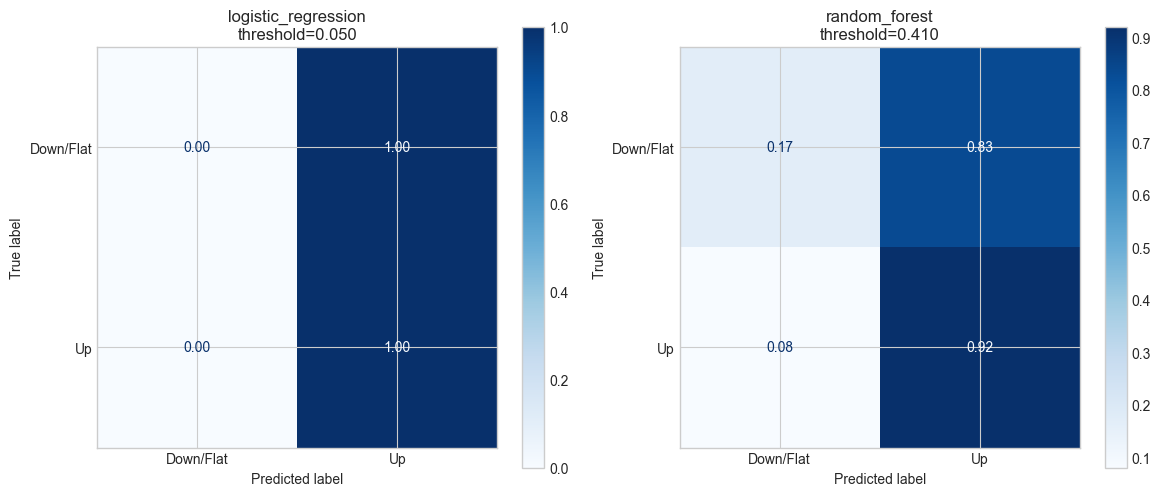

In [76]:
test_metrics = metrics_df[metrics_df['split'] == 'test'].copy()
fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5))
if len(models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, models.keys()):
    threshold = test_metrics.loc[test_metrics['model'] == model_name, 'threshold'].iloc[0]
    pred = predictions_df[(predictions_df['model'] == model_name) & (predictions_df['split'] == 'test')]
    ConfusionMatrixDisplay.from_predictions(
        pred['target'],
        pred['y_pred'],
        display_labels=['Down/Flat', 'Up'],
        normalize='true',
        cmap='Blues',
        ax=ax,
        values_format='.2f',
    )
    ax.set_title(f'{model_name}\nthreshold={threshold:.3f}')

plt.tight_layout()
plt.show()

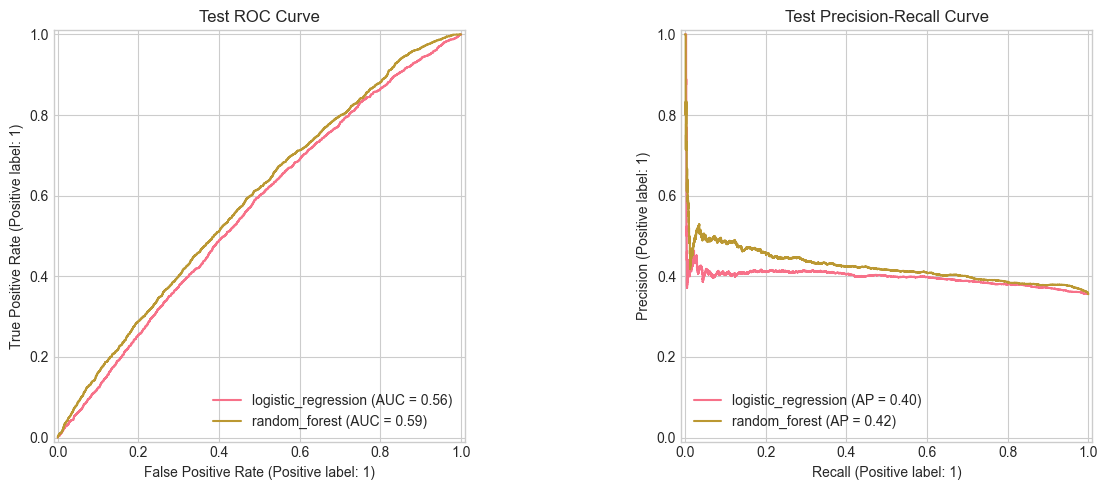

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for model_name in models.keys():
    pred = predictions_df[(predictions_df['model'] == model_name) & (predictions_df['split'] == 'test')]
    RocCurveDisplay.from_predictions(pred['target'], pred['y_score'], name=model_name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(pred['target'], pred['y_score'], name=model_name, ax=axes[1])

axes[0].set_title('Test ROC Curve')
axes[1].set_title('Test Precision-Recall Curve')
plt.tight_layout()
plt.show()

---
## Section 12: Sector And Time Slice Checks

In [78]:
def grouped_binary_metrics(frame, group_cols):
    rows = []
    for key, group in frame.groupby(group_cols):
        if not isinstance(key, tuple):
            key = (key,)
        y_true = group['target'].astype(int)
        y_pred = group['y_pred'].astype(int)
        y_score = group['y_score']
        row = {col: val for col, val in zip(group_cols, key)}
        row.update({
            'n': len(group),
            'positive_rate': y_true.mean(),
            'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
            'precision_up': precision_score(y_true, y_pred, zero_division=0),
            'recall_up': recall_score(y_true, y_pred, zero_division=0),
            'f1_up': f1_score(y_true, y_pred, zero_division=0),
            'roc_auc': safe_roc_auc(y_true, y_score),
        })
        rows.append(row)
    return pd.DataFrame(rows)

analysis_df = predictions_df[predictions_df['split'] == 'test'].copy()
analysis_df['year'] = analysis_df['target_date'].dt.year
analysis_df['quarter'] = analysis_df['target_date'].dt.to_period('Q').astype(str)

for model_name in models.keys():
    print(f'\nSector metrics: {model_name}')
    display(grouped_binary_metrics(analysis_df[analysis_df['model'] == model_name], ['sector']).round(4))

    print(f'Quarter metrics: {model_name}')
    display(grouped_binary_metrics(analysis_df[analysis_df['model'] == model_name], ['quarter']).round(4))


Sector metrics: logistic_regression


,sector,n,positive_rate,balanced_accuracy,precision_up,recall_up,f1_up,roc_auc
0,Energy,4315,0.3866,0.5,0.3866,1.0,0.5576,0.5457
1,Technology,2986,0.3111,0.5,0.3111,1.0,0.4746,0.5647


Quarter metrics: logistic_regression


,quarter,n,positive_rate,balanced_accuracy,precision_up,recall_up,f1_up,roc_auc
0,2024Q1,4999,0.3541,0.5,0.3541,1.0,0.5230,0.5554
1,2024Q2,2302,0.3593,0.5,0.3593,1.0,0.5286,0.5766



Sector metrics: random_forest


,sector,n,positive_rate,balanced_accuracy,precision_up,recall_up,f1_up,roc_auc
0,Energy,4315,0.3866,0.5371,0.4065,0.9269,0.5652,0.5733
1,Technology,2986,0.3111,0.5494,0.3364,0.9064,0.4907,0.5873


Quarter metrics: random_forest


,quarter,n,positive_rate,balanced_accuracy,precision_up,recall_up,f1_up,roc_auc
0,2024Q1,4999,0.3541,0.5453,0.3780,0.9220,0.5362,0.5824
1,2024Q2,2302,0.3593,0.5391,0.3801,0.9141,0.5369,0.5944


---
## Section 13: Feature Importance

These interpretation tables use the final capped 40-feature model matrix, not the full 77-feature candidate set.

In [79]:
# Importance tables now describe the final 40-feature model matrix.
if len(feature_cols) != FEATURE_CAP:
    raise ValueError(f'Expected {FEATURE_CAP} selected features, found {len(feature_cols)}')

importance_frames = []

if 'random_forest' in fitted_models:
    rf = fitted_models['random_forest'].named_steps['model']
    importance_frames.append(pd.DataFrame({
        'model': 'random_forest',
        'feature': feature_cols,
        'importance': rf.feature_importances_,
    }))

if 'logistic_regression' in fitted_models:
    lr = fitted_models['logistic_regression'].named_steps['model']
    importance_frames.append(pd.DataFrame({
        'model': 'logistic_regression',
        'feature': feature_cols,
        'importance': np.abs(lr.coef_[0]),
    }))

feature_importance_df = pd.concat(importance_frames, ignore_index=True)
importance_path = MODEL_OUTPUT_DIR / 'feature_importance.csv'
feature_importance_df.to_csv(importance_path, index=False)

for model_name in feature_importance_df['model'].unique():
    print(f'\nTop selected features: {model_name}')
    display(feature_importance_df[feature_importance_df['model'] == model_name]
            .sort_values('importance', ascending=False)
            .head(15)
            .round(6))

print(f'Saved 40-feature importance table to: {importance_path}')


Top selected features: random_forest


,model,feature,importance
1,random_forest,high_low_spread,0.040184
0,random_forest,price_vs_ma5,0.038150
2,random_forest,price_position,0.034861
4,random_forest,price_vs_ma10,0.033939
3,random_forest,volume_ratio_50d,0.033081
5,random_forest,log_volume,0.030614
7,random_forest,volatility_5d,0.029487
10,random_forest,price_vs_ma50,0.028709
9,random_forest,high_low_spread_lag1,0.028422
12,random_forest,dist_from_low50,0.027793



Top selected features: logistic_regression


,model,feature,importance
44,logistic_regression,price_vs_ma10,0.232432
50,logistic_regression,price_vs_ma50,0.170637
70,logistic_regression,dist_from_high10,0.154097
42,logistic_regression,price_position,0.143149
71,logistic_regression,momentum_20d,0.113536
51,logistic_regression,momentum_50d,0.110590
45,logistic_regression,log_volume,0.099805
52,logistic_regression,dist_from_low50,0.099712
53,logistic_regression,volatility_10d,0.093980
65,logistic_regression,momentum_10d,0.087606


Saved 40-feature importance table to: Dataset\model_outputs\feature_importance.csv


---
## Section 14: Final Model Feature Importance

This section exports the Random-Forest-only importance table for the final model, limited to the selected 40 features.

In [80]:
rf_importance = feature_importance_df[
    feature_importance_df['model'] == FINAL_MODEL
].copy()
if rf_importance.empty:
    raise ValueError('Random Forest feature importance was not found')

rf_importance = rf_importance.sort_values('importance', ascending=False).reset_index(drop=True)
rf_importance_path = MODEL_OUTPUT_DIR / 'random_forest_feature_importance.csv'
rf_importance.to_csv(rf_importance_path, index=False)

print(f'Saved Random Forest feature importance to: {rf_importance_path}')
display(rf_importance.head(20).round(6))

Saved Random Forest feature importance to: Dataset\model_outputs\random_forest_feature_importance.csv


,model,feature,importance
0,random_forest,high_low_spread,0.040184
1,random_forest,price_vs_ma5,0.038150
2,random_forest,price_position,0.034861
3,random_forest,price_vs_ma10,0.033939
4,random_forest,volume_ratio_50d,0.033081
5,random_forest,log_volume,0.030614
6,random_forest,volatility_5d,0.029487
7,random_forest,price_vs_ma50,0.028709
8,random_forest,high_low_spread_lag1,0.028422
9,random_forest,dist_from_low50,0.027793
